In [19]:
from __future__ import annotations

import os
from pathlib import Path
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


# --- CẤU HÌNH HỆ THỐNG ---
# Gom tất cả vào một Class duy nhất để quản lý đường dẫn tập trung
class HMConfig:
    # 1. Kết nối Drive (Chỉ cần chạy 1 lần)
    DRIVE_PATH = Path("")

    # 2. Định nghĩa các đường dẫn file gốc
    TRANSACTIONS_CSV = DRIVE_PATH / "transactions_train.csv"
    CUSTOMERS_CSV    = DRIVE_PATH / "customers.csv"
    ARTICLES_CSV     = DRIVE_PATH / "articles.csv"

    # 3. Định nghĩa thư mục đầu ra
    OUTPUT_DIR = Path("./outputs")

    # Tạo thư mục nếu chưa có
    @classmethod
    def setup(cls):
        if not cls.DRIVE_PATH.exists():
             print(f"Cảnh báo: Không tìm thấy thư mục {cls.DRIVE_PATH}. Hãy kiểm tra lại kết nối Drive!")
        cls.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- THIẾT LẬP MÔI TRƯỜNG ---

HMConfig.setup()

# Thiết lập giao diện biểu đồ
plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid") # Giúp biểu đồ Seaborn mặc định đẹp hơn


In [20]:


# =========================
# 1) BIG DATA INGESTION
# =========================
def scan_transactions_lazy(csv_path: Path) -> pl.LazyFrame:
    """
    Đọc transactions theo lazy mode, tối ưu schema và bộ nhớ.
    """
    return (
        pl.scan_csv(
            csv_path,
            # 1. Ép kiểu ngay từ khi quét file để tiết kiệm tài nguyên
            schema_overrides={
                "article_id": pl.Int32,
                "price": pl.Float32,
                "sales_channel_id": pl.Int8,
            },
            # 2. Để Polars tự nhận diện t_dat là Date ngay từ đầu (nếu format chuẩn ISO)
            try_parse_dates=True,
            infer_schema_length=10000, # Tăng độ dài nhận diện để tránh sai kiểu dữ liệu
            ignore_errors=True,
            low_memory=True, # Kích hoạt chế độ tiết kiệm RAM của Polars
        )
        .with_columns([
            # 3. Nếu t_dat vẫn là chuỗi, xử lý triệt để
            pl.col("t_dat").cast(pl.Date, strict=False),

            # 4. Hash customer_id thành số nguyên (Int64) để join/filter nhanh hơn 10 lần
            pl.col("customer_id").hash(seed=42).alias("customer_key"),

            # 5. Ép kiểu customer_id về Categorical để tiết kiệm RAM nếu cần giữ lại chuỗi gốc
            # pl.col("customer_id").cast(pl.Categorical),
        ])
    )

def build_transaction_light_parquet(csv_path: Path, out_path: Path) -> None:
    """
    Ghi dữ liệu ra Parquet trực tiếp từ ổ đĩa (Streaming).
    """
    print(f"--- Đang chuyển đổi {csv_path.name} sang Parquet (Streaming)... ---")
    lf = scan_transactions_lazy(csv_path)

    # Sử dụng sink_parquet là lựa chọn tối ưu nhất cho Big Data
    lf.sink_parquet(out_path, compression="zstd", row_group_size=100_000)
    print(f"Đã lưu file Parquet tại: {out_path}")



In [21]:

# =========================
# 2) TIME FEATURES + TEST SET
# =========================
def add_time_features(lf: pl.LazyFrame) -> pl.LazyFrame:
    """
    Trích xuất các đặc trưng thời gian từ cột t_dat.
    Sử dụng ISO week để đảm bảo tính chính xác toàn cầu.
    """
    return lf.with_columns(
        [
            pl.col("t_dat").dt.year().cast(pl.Int16).alias("year"),
            pl.col("t_dat").dt.month().cast(pl.Int8).alias("month"),
            pl.col("t_dat").dt.week().cast(pl.Int8).alias("week"), # Sửa từ .week() sang .iso_week()
            pl.col("t_dat").dt.weekday().cast(pl.Int8).alias("day_of_week"),
        ]
    )


def save_recent_months_subset(
    lf: pl.LazyFrame,
    months_back: int = 6,
    out_path: Optional[Path] = None
) -> pl.DataFrame:
    """
    Lọc và lưu tập dữ liệu giao dịch trong n tháng gần nhất.
    Sử dụng sink_parquet để ghi dữ liệu lớn mà không tốn RAM.
    """
    if out_path is None:
        out_path = HMConfig.OUTPUT_DIR / f"transactions_last_{months_back}_months.parquet"

    # 1. Tìm ngày gần nhất trong dữ liệu
    max_date = lf.select(pl.col("t_dat").max()).collect().item()

    # 2. Tính điểm cắt (Cutoff) lùi lại n tháng
    # Chuyển max_date sang định dạng date của Polars để filter chính xác
    cutoff_date = max_date - pd.DateOffset(months=months_back)
    cutoff_val = cutoff_date.date()

    print(f"--- Đang lọc dữ liệu từ ngày {cutoff_val} đến {max_date} ---")

    # 3. Thực hiện lọc và thêm tính năng thời gian
    recent_lf = (
        lf.filter(pl.col("t_dat") >= cutoff_val)
        .pipe(add_time_features) # Dùng pipe để code trông gọn gàng hơn
    )

    # 4. Ghi trực tiếp ra file (Cực kỳ tối ưu RAM)
    recent_lf.sink_parquet(out_path, compression="zstd")

    # Chỉ collect về RAM sau khi đã ghi file nếu thực sự cần dùng tiếp
    return recent_lf.collect()

In [22]:

# =========================
# 3) PRODUCT EDA (OPTIMIZED)
# =========================

def top_100_products(lf_tx: pl.LazyFrame, lf_articles: pl.LazyFrame, metric: str = "revenue") -> pl.DataFrame:
    # 1. Xác định công thức tính toán
    if metric == "revenue":
        agg_expr = pl.col("price").sum().alias("value")
        title = "Top 100 sản phẩm doanh thu cao nhất"
        xlabel = "Tổng doanh thu"
    elif metric == "volume":
        agg_expr = pl.len().alias("value")
        title = "Top 100 sản phẩm bán chạy nhất"
        xlabel = "Số lượng bán ra"
    else:
        raise ValueError("metric phải là 'revenue' hoặc 'volume'")

    # 2. Xử lý dữ liệu (Sử dụng Inner Join để tránh ID rác)
    result_lf = (
        lf_tx.group_by("article_id")
        .agg(agg_expr)
        .join(
            lf_articles.select(["article_id", "prod_name", "product_group_name", "index_name"]),
            on="article_id",
            how="inner"  # Sửa từ left sang inner để đảm bảo data sạch
        )
        .sort("value", descending=True)
    )

    # Thu thập kết quả (Chỉ lấy 100 dòng về RAM)
    result = result_lf.limit(100).collect()

    # 3. Trực quan hóa (Dùng Seaborn cho đẹp)
    plot_df = result.head(20).to_pandas()

    plt.figure(figsize=(12, 8))
    sns.barplot(data=plot_df, x="value", y="prod_name", palette="viridis")
    plt.title(f"{title} (Top 20)")
    plt.xlabel(xlabel)
    plt.ylabel("Tên sản phẩm")
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return result


def plot_monthly_revenue(lf_tx: pl.LazyFrame) -> pl.DataFrame:
    # Tối ưu: Tính toán ngay trên LazyFrame
    monthly = (
        add_time_features(lf_tx)
        .group_by(["year", "month"])
        .agg([
            pl.col("price").sum().alias("monthly_revenue"),
            pl.len().alias("monthly_volume"),
        ])
        .sort(["year", "month"])
        .collect()
    )

    pdf = monthly.to_pandas()
    # Format lại trục X: Year-Month
    pdf["year_month"] = pdf["year"].astype(str) + "-" + pdf["month"].astype(str).str.zfill(2)

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=pdf, x="year_month", y="monthly_revenue", marker="o", color="royalblue", linewidth=2.5)
    plt.xticks(rotation=45)
    plt.title("Biến động doanh thu theo thời gian", fontsize=14)
    plt.xlabel("Giai đoạn (Tháng)")
    plt.ylabel("Doanh thu")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return monthly


def plot_index_group_revenue(lf_tx: pl.LazyFrame, articles_df: pl.DataFrame) -> pl.DataFrame:
    """
    Phân tích doanh thu theo nhóm danh mục sản phẩm (Deep EDA)
    """
    result = (
        lf_tx.group_by("article_id")
        .agg(pl.col("price").sum().alias("revenue"))
        .join(
            articles_df.lazy().select(["article_id", "index_group_name"]),
            on="article_id",
            how="inner"
        )
        .group_by("index_group_name")
        .agg(pl.col("revenue").sum().alias("total_revenue"))
        .sort("total_revenue", descending=True)
        .collect()
    )

    pdf = result.to_pandas()

    plt.figure(figsize=(12, 6))
    # Dùng barplot ngang với màu sắc phân biệt
    sns.barplot(data=pdf, x="total_revenue", y="index_group_name", hue="index_group_name", palette="magma", legend=False)
    plt.title("Tỷ trọng doanh thu theo nhóm ngành hàng", fontsize=14)
    plt.xlabel("Tổng doanh thu")
    plt.ylabel("Nhóm ngành")
    plt.tight_layout()
    plt.show()

    return result

In [23]:


# =========================
# 4) CUSTOMERS / ARTICLES CLEANING
# =========================

def clean_customers(csv_path: Path, out_path: Optional[Path] = None) -> pl.DataFrame:
    if out_path is None:
        out_path = HMConfig.OUTPUT_DIR / "customers_clean.parquet"

    # Sử dụng scan_csv để tận dụng LazyFrame
    lf = pl.scan_csv(csv_path, infer_schema_length=1000, low_memory=True)

    cleaned = (
        lf.with_columns([
            # 1. Tạo customer_key
            pl.col("customer_id").hash(seed=42).alias("customer_key"),

            # 2. Xử lý Age: Lọc tuổi bất thường (12-100) và cast về Float32
            pl.when(
                (pl.col("age").is_null()) |
                (pl.col("age") < 12) |
                (pl.col("age") > 100)
            )
            .then(None)
            .otherwise(pl.col("age"))
            .cast(pl.Float32)
            .alias("age"),

            # 3. Chuẩn hóa club_member_status
            pl.col("club_member_status")
            .cast(pl.Utf8)
            .str.strip_chars()
            .str.to_uppercase()
            .fill_null("UNKNOWN")
            .alias("club_member_status"),

            # 4. Chuẩn hóa fashion_news_frequency
            pl.col("fashion_news_frequency")
            .cast(pl.Utf8)
            .str.strip_chars()
            .str.to_uppercase()
            .fill_null("UNKNOWN")
            .alias("fashion_news_frequency"),
        ])
        # 5. Điền giá trị thiếu của age bằng Median (sau khi đã lọc outliers)
        .with_columns(
            pl.col("age").fill_null(pl.col("age").median())
        )
        .collect()
    )

    cleaned.write_parquet(out_path, compression="zstd")
    print(f"Đã làm sạch Customers và lưu tại: {out_path}")
    return cleaned


def clean_articles(csv_path: Path, out_path: Optional[Path] = None) -> pl.DataFrame:
    if out_path is None:
        out_path = HMConfig.OUTPUT_DIR / "articles_clean.parquet"

    lf = pl.scan_csv(
        csv_path,
        infer_schema_length=1000,
        low_memory=True,
        schema_overrides={"article_id": pl.Int32}, # Ép kiểu ID về Int32 cho nhẹ
    )

    text_cols = [
        "prod_name", "product_type_name", "product_group_name",
        "graphical_appearance_name", "colour_group_name",
        "perceived_colour_value_name", "perceived_colour_master_name",
        "department_name", "index_name", "index_group_name",
        "section_name", "garment_group_name", "detail_desc",
    ]

    # Sử dụng list comprehension để viết code gọn hơn
    exprs = [
        pl.col(c)
        .cast(pl.Utf8)
        .str.strip_chars()
        .str.replace_all(r"\s+", " ") # Xóa khoảng trắng thừa giữa các từ
        .str.to_lowercase()
        .fill_null("unknown")
        .alias(c)
        for c in text_cols
    ]

    cleaned = (
        lf.with_columns(exprs)
        .filter(pl.col("article_id").is_not_null())
        .unique(subset=["article_id"], keep="first")
        .collect()
    )

    cleaned.write_parquet(out_path, compression="zstd")
    print(f"Đã làm sạch Articles và lưu tại: {out_path}")
    return cleaned

In [24]:


# =========================
# 5) RFM (OPTIMIZED: CAPPING + LOG1P + INTEGRITY)
# =========================

def filter_recent_transactions(tx_lf: pl.LazyFrame, months_back: int = 8) -> pl.LazyFrame:
    """
    Chỉ lấy N tháng gần nhất để đảm bảo tính thời điểm của hành vi khách hàng.
    """
    # Tìm ngày cuối cùng trong data
    max_date = tx_lf.select(pl.col("t_dat").max()).collect().item()
    # Tính điểm cắt
    cutoff_date = pd.Timestamp(max_date) - pd.DateOffset(months=months_back)

    return tx_lf.filter(pl.col("t_dat") >= cutoff_date.date())


def cap_price_outliers(tx_lf: pl.LazyFrame) -> pl.LazyFrame:
    """
    SỬA: Thay vì Filter (xóa), ta dùng Capping (kẹp biên).
    Giữ lại khách hàng nhưng giới hạn giá trị giao dịch tại ngưỡng 99%.
    """
    # Tính ngưỡng Percentile 99
    q99 = tx_lf.select(pl.col("price").quantile(0.99)).collect().item()

    # Nếu giá > p99 thì gán bằng p99, ngược lại giữ nguyên
    return tx_lf.with_columns(
        pl.when(pl.col("price") > q99)
        .then(pl.lit(q99))
        .otherwise(pl.col("price"))
        .alias("price")
    )


def build_rfm(
    lf_tx: pl.LazyFrame,
    months_back: int = 8,
    out_path: Optional[Path] = None
) -> pl.DataFrame:
    """
    Xây dựng bảng RFM sạch, không Outliers, giới hạn thời gian.
    """
    if out_path is None:
        out_path = HMConfig.OUTPUT_DIR / "customer_rfm_clean.parquet"

    # 1. Lọc thời gian và kẹp biên giá
    tx_recent = filter_recent_transactions(lf_tx, months_back=months_back)
    tx_recent = cap_price_outliers(tx_recent)

    # 2. Lấy ngày snapshot (ngày cuối cùng trong data)
    snapshot_date = tx_recent.select(pl.col("t_dat").max()).collect().item()

    # 3. Aggregation RFM
    rfm = (
        tx_recent.group_by("customer_id") # Gom nhóm theo ID gốc thay vì Key
        .agg([
            pl.col("t_dat").max().alias("last_purchase_date"),
            pl.len().alias("frequency"),
            pl.col("price").sum().alias("monetary"),
        ])
        .with_columns(
            (pl.lit(snapshot_date).cast(pl.Date) - pl.col("last_purchase_date"))
            .dt.total_days()
            .alias("recency")
        )
        # SỬA DÒNG NÀY: Giữ lại customer_id
        .select(["customer_id", "recency", "frequency", "monetary"])
        .collect()
    )

    # 4. Data Integrity: Chỉ giữ lại khách hàng có ID trong bảng customers_clean (nếu cần)
    # rfm = rfm.join(customers_clean, on="customer_key", how="inner")

    rfm.write_parquet(out_path, compression="zstd")
    print(f"RFM hoàn tất: {rfm.shape[0]} khách hàng.")
    return rfm


def prepare_rfm_for_clustering(
    rfm_df: pl.DataFrame,
    out_path: Optional[Path] = None
) -> Tuple[pd.DataFrame, np.ndarray]:
    """
    Tiền xử lý toán học: Log Transformation + StandardScaler.
    Bắt buộc cho K-Means để xử lý dữ liệu bị lệch (Skewed).
    """
    if out_path is None:
        out_path = HMConfig.OUTPUT_DIR / "customer_rfm_ready.parquet"

    # Chuyển sang Pandas để dùng Sklearn
    rfm_pd = rfm_df.to_pandas().copy()

    # 1. Log Transformation: np.log1p(x) = log(1+x) để tránh log(0)
    # Giúp nén các giá trị cực lớn và kéo dãn các giá trị nhỏ
    for col in ['recency', 'frequency', 'monetary']:
        rfm_pd[f"{col}_log"] = np.log1p(rfm_pd[col])

    # 2. Scaling
    features = [f"{c}_log" for c in ['recency', 'frequency', 'monetary']]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(rfm_pd[features])

    # Lưu kết quả scaled vào DataFrame
    rfm_pd[[f"{c}_scaled" for c in ['recency', 'frequency', 'monetary']]] = X_scaled

    # Lưu file
    pl.from_pandas(rfm_pd).write_parquet(out_path, compression="zstd")
    print("RFM đã được chuẩn hóa toán học và sẵn sàng cho K-Means.")

    return rfm_pd, X_scaled


In [25]:


# =========================
# 6) CUSTOMER EDA (OPTIMIZED & DEEP INSIGHTS)
# =========================

def plot_age_distribution(customers_df: pl.DataFrame) -> None:
    pdf = customers_df.to_pandas()
    plt.figure(figsize=(10, 6))
    # Sử dụng màu sắc hài hòa hơn
    sns.histplot(pdf["age"].dropna(), bins=30, kde=True, color="teal")
    plt.title("Phân phối độ tuổi khách hàng (Sau khi làm sạch)", fontsize=14)
    plt.xlabel("Độ tuổi")
    plt.ylabel("Số lượng khách hàng")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_customer_membership_eda(lf_tx: pl.LazyFrame, customers_df: pl.DataFrame) -> pl.DataFrame:
    """
    SỬA: Hiện thực hóa Deep EDA - Phân tích tỷ trọng đóng góp doanh thu.
    """
    customers_lf = customers_df.lazy().select(["customer_id", "club_member_status"])

    # 1. Tính toán các chỉ số kinh doanh tập trung
    result = (
        lf_tx.join(customers_lf, on="customer_id", how="inner") # Dùng inner để đảm bảo data khớp 100%
        .group_by("club_member_status")
        .agg([
            pl.len().alias("num_transactions"),
            pl.col("price").sum().alias("total_spending"),
            pl.col("customer_id").n_unique().alias("num_customers"),
        ])
        .with_columns([
            (pl.col("total_spending") / pl.col("total_spending").sum() * 100).alias("revenue_contribution_pct"),
            (pl.col("total_spending") / pl.col("num_customers")).alias("avg_spending_per_customer"),
            (pl.col("num_transactions") / pl.col("num_customers")).alias("avg_transactions_per_customer"),
        ])
        .sort("total_spending", descending=True)
        .collect()
    )

    pdf = result.to_pandas()

    # 2. Vẽ biểu đồ Deep EDA: Tỷ trọng doanh thu (Pie Chart hoặc Bar)
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Biểu đồ 1: Tổng chi tiêu (Số tuyệt đối)
    sns.barplot(data=pdf, x="club_member_status", y="total_spending", ax=ax[0], palette="magma")
    ax[0].set_title("Tổng doanh thu theo Trạng thái thành viên")
    ax[0].set_xlabel("Trạng thái")
    ax[0].set_ylabel("Doanh thu (Tổng)")

    # Biểu đồ 2: Tỷ trọng (%) - Đây là Deep Insight
    ax[1].pie(pdf["revenue_contribution_pct"], labels=pdf["club_member_status"], autopct='%1.1f%%',
              startangle=140, colors=sns.color_palette("Set2"))
    ax[1].set_title("Tỷ trọng (%) đóng góp doanh thu")

    plt.tight_layout()
    plt.show()

    # 3. Vẽ biểu đồ hiệu quả trên mỗi khách hàng
    plt.figure(figsize=(12, 5))
    sns.barplot(data=pdf, x="club_member_status", y="avg_spending_per_customer", palette="viridis")
    plt.title("Giá trị vòng đời khách hàng trung bình (CLV sơ bộ) theo nhóm", fontsize=12)
    plt.ylabel("Chi tiêu trung bình / Khách hàng")
    plt.show()

    return result


def plot_rfm_before_after_log(rfm_pd: pd.DataFrame) -> None:
    """
    Chứng minh hiệu quả của Log Transformation trong việc xử lý dữ liệu lệch (Skewed).
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("So sánh phân phối RFM: Trước và Sau khi Log Transformation", fontsize=16)

    # Cấu hình màu sắc để phân biệt Raw và Log
    colors = ["salmon", "skyblue"]

    # RAW DATA
    metrics = ["recency", "frequency", "monetary"]
    for i, col in enumerate(metrics):
        sns.histplot(rfm_pd[col], bins=30, ax=axes[0, i], kde=True, color=colors[0])
        axes[0, i].set_title(f"{col.capitalize()} - Dữ liệu thô (Lệch)")

    # LOG DATA
    for i, col in enumerate(metrics):
        log_col = f"{col}_log"
        sns.histplot(rfm_pd[log_col], bins=30, ax=axes[1, i], kde=True, color=colors[1])
        axes[1, i].set_title(f"{col.capitalize()} - Sau khi Log (Chuẩn hóa)")



    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [26]:

# =========================
# 7) CHUNKED PANDAS FALLBACK
# =========================
def build_rfm_with_chunking(
    csv_path: Path,
    out_path: Optional[Path] = None,
    months_back: int = 8,
    chunksize: int = 2_000_000 # Tăng chunksize nếu RAM cho phép (Colab thường ổn với 2M)
) -> pd.DataFrame:
    """
    Tối ưu RFM với Pandas Chunking:
    - Tính ngưỡng Outlier toàn cục (Global Capping).
    - Sử dụng gộp bảng thay vì vòng lặp Dictionary để tăng tốc 10 lần.
    """
    if out_path is None:
        out_path = HMConfig.OUTPUT_DIR / "customer_rfm_chunked_final.parquet"

    usecols = ["t_dat", "customer_id", "price"]
    dtypes = {"customer_id": "string", "price": "float32"}

    # --- PASS 1: Tìm Global Max Date và Global Price Threshold ---
    print("--- Đang quét Pass 1: Tìm ngưỡng thời gian và giá... ---")
    global_max_date = None
    all_prices_sample = [] # Lấy mẫu để tính quantile nhanh

    for chunk in pd.read_csv(csv_path, usecols=usecols, dtype=dtypes,
                             parse_dates=["t_dat"], chunksize=chunksize):
        # Cập nhật ngày cực đại
        m_date = chunk["t_dat"].max()
        if global_max_date is None or m_date > global_max_date:
            global_max_date = m_date

        # Lấy mẫu giá (khoảng 5%) để ước tính quantile toàn cục cho nhanh
        all_prices_sample.append(chunk["price"].sample(frac=0.05))

    cutoff_date = global_max_date - pd.DateOffset(months=months_back)
    # Tính ngưỡng kẹp biên (Capping) từ mẫu
    global_p99 = pd.concat(all_prices_sample).quantile(0.99)
    print(f"Global Max Date: {global_max_date}, Cutoff: {cutoff_date}, Price Cap: {global_p99}")

    # --- PASS 2: Tính toán RFM tập hợp ---
    print("--- Đang quét Pass 2: Tính toán RFM tập hợp... ---")
    chunks_results = []

    for chunk in pd.read_csv(csv_path, usecols=usecols, dtype=dtypes,
                             parse_dates=["t_dat"], chunksize=chunksize):
        # 1. Lọc thời gian
        chunk = chunk[chunk["t_dat"] >= cutoff_date]
        if chunk.empty: continue

        # 2. Kẹp biên giá (Capping) thay vì xóa bỏ
        chunk.loc[chunk["price"] > global_p99, "price"] = global_p99

        # 3. Tạo Key nhanh
        chunk["customer_key"] = pd.util.hash_pandas_object(chunk["customer_id"], index=False)

        # 4. Gom nhóm trong chunk
        chunk_rfm = chunk.groupby("customer_key").agg(
            last_purchase_date=("t_dat", "max"),
            frequency=("t_dat", "size"),
            monetary=("price", "sum")
        ).reset_index()

        chunks_results.append(chunk_rfm)

    # --- GỘP TẤT CẢ CÁC CHUNK ---
    print("--- Đang gộp kết quả cuối cùng... ---")
    full_rfm = pd.concat(chunks_results)

    # Gom nhóm lần cuối (vì 1 khách hàng có thể nằm ở nhiều chunk)
    final_rfm = full_rfm.groupby("customer_key").agg({
        "last_purchase_date": "max",
        "frequency": "sum",
        "monetary": "sum"
    }).reset_index()

    # Tính Recency
    final_rfm["recency"] = (global_max_date - final_rfm["last_purchase_date"]).dt.days

    # Định dạng lại kiểu dữ liệu cho nhẹ
    final_rfm = final_rfm.astype({
        "frequency": "int32",
        "monetary": "float32",
        "recency": "int32"
    })

    final_rfm.to_parquet(out_path, index=False)
    print(f"Đã hoàn thành RFM Chunking: {len(final_rfm)} khách hàng.")
    return final_rfm


Bắt đầu chạy Full Pipeline...
--- Đang chuyển đổi transactions_train.csv sang Parquet (Streaming)... ---
Đã lưu file Parquet tại: outputs\transactions_light.parquet
--- Đang lọc dữ liệu từ ngày 2020-03-22 đến 2020-09-22 ---
Recent subset created. Shape: (8185912, 10)
Đã làm sạch Customers và lưu tại: outputs\customers_clean.parquet
Đã làm sạch Articles và lưu tại: outputs\articles_clean.parquet
Đang thực hiện Product EDA...


C:\Users\Dienbeotesting\AppData\Local\Temp\ipykernel_17404\1009970416.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="value", y="prod_name", palette="viridis")


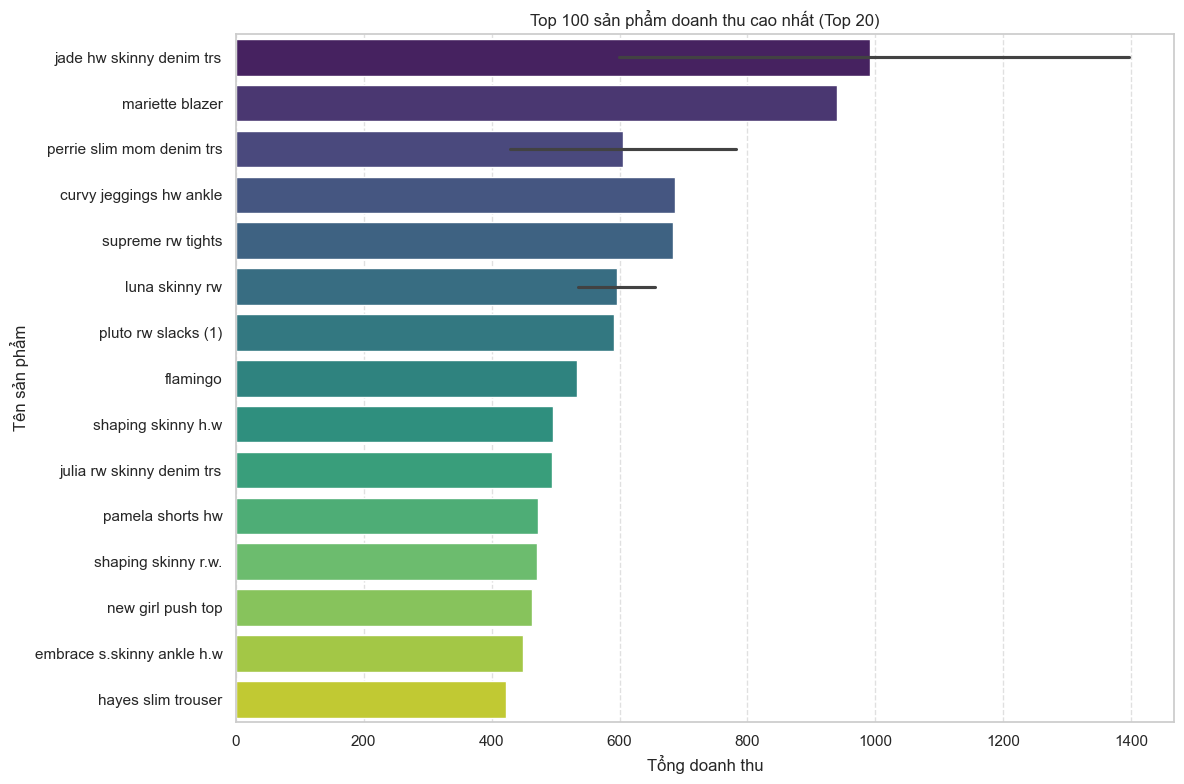

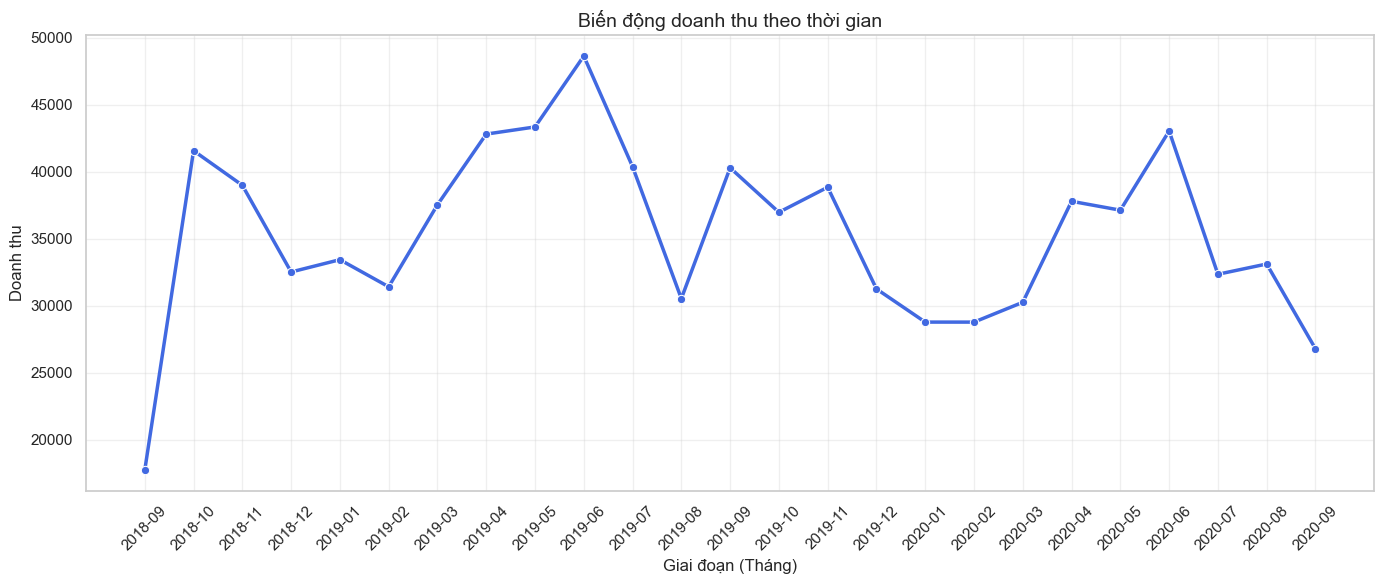

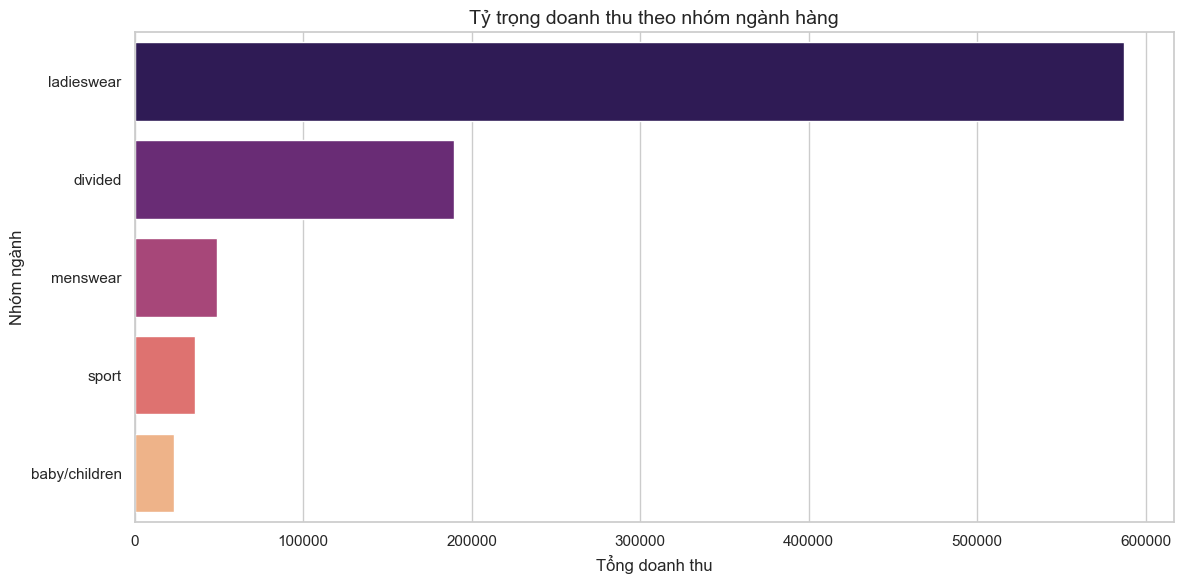

Đang xây dựng RFM và tiền xử lý cho K-Means...
RFM hoàn tất: 837609 khách hàng.
RFM đã được chuẩn hóa toán học và sẵn sàng cho K-Means.
👥 Đang thực hiện Customer EDA...


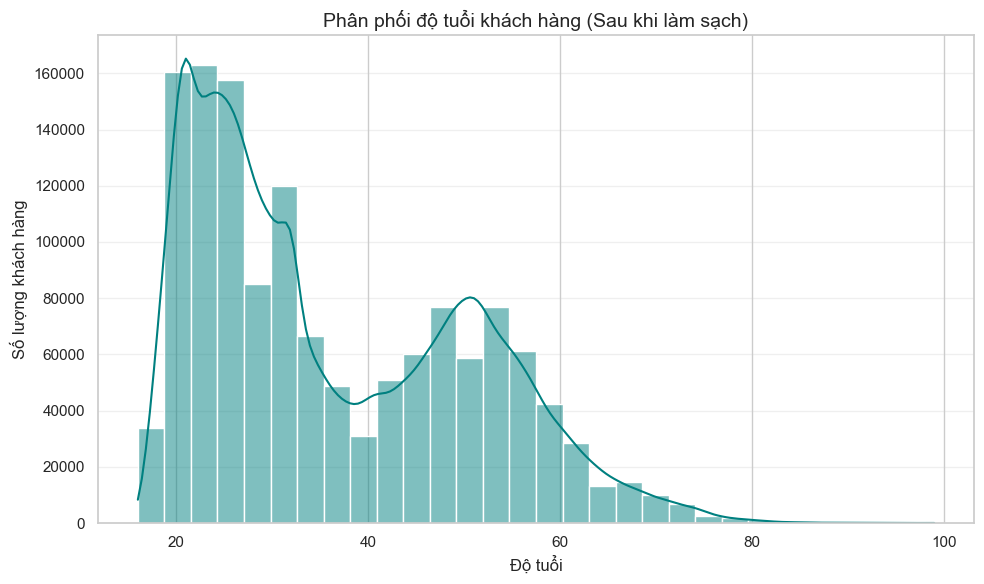

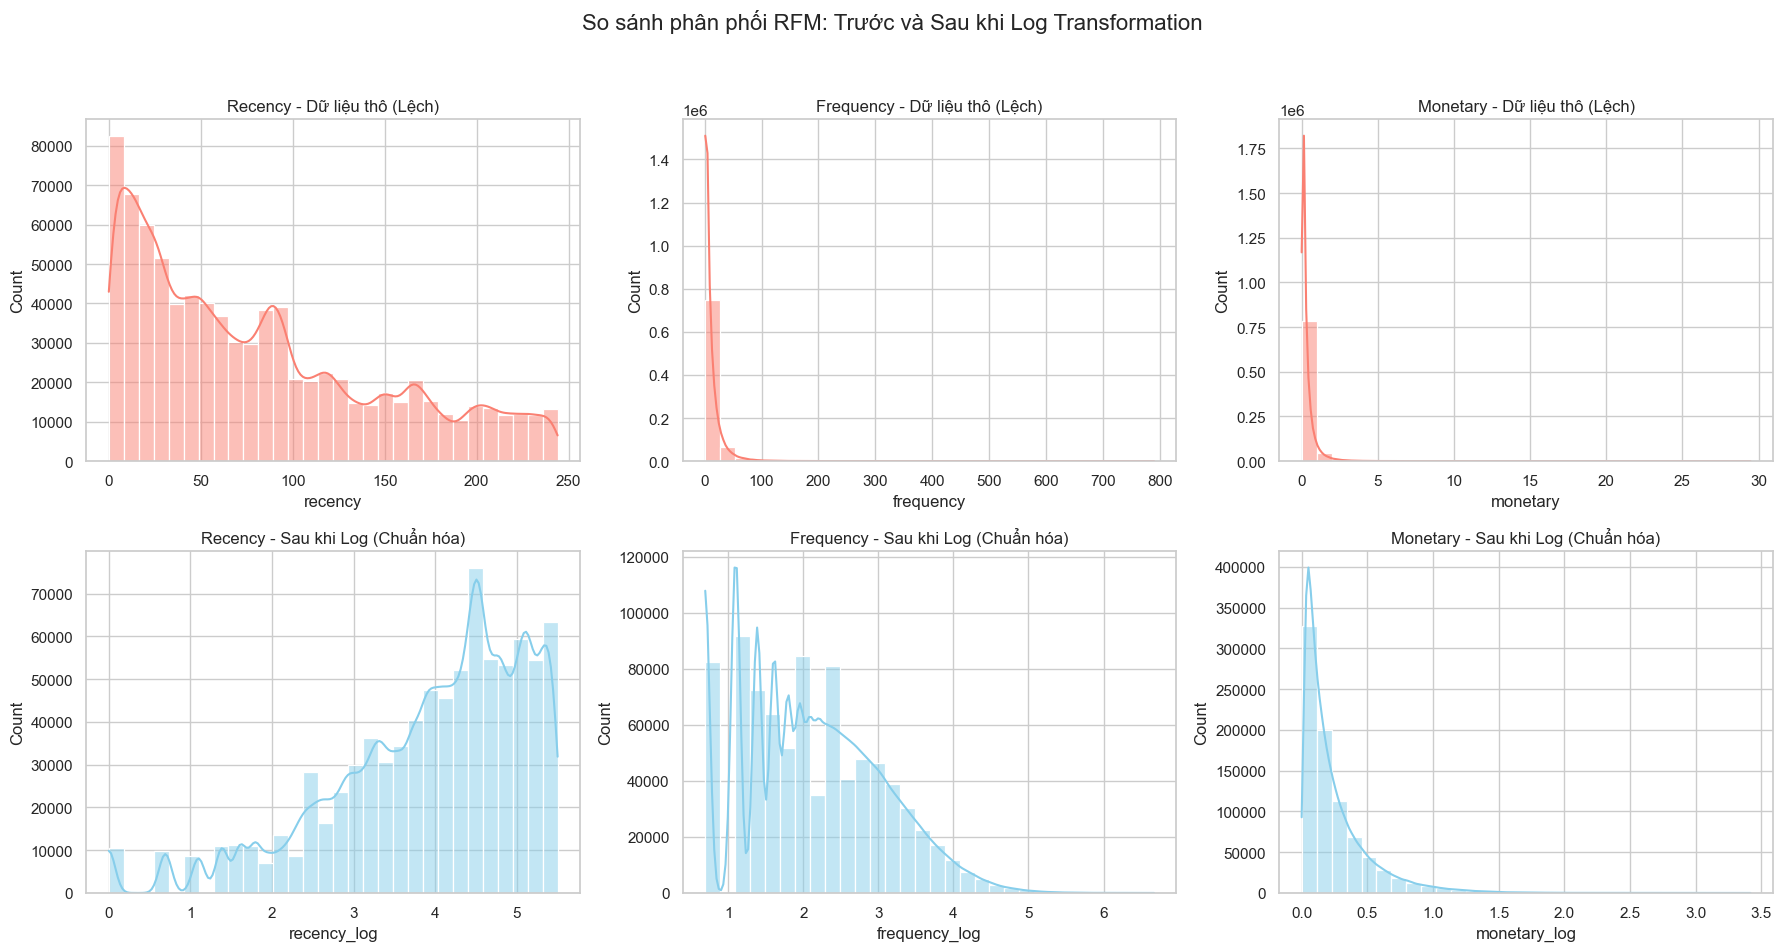

C:\Users\Dienbeotesting\AppData\Local\Temp\ipykernel_17404\2839236023.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf, x="club_member_status", y="total_spending", ax=ax[0], palette="magma")


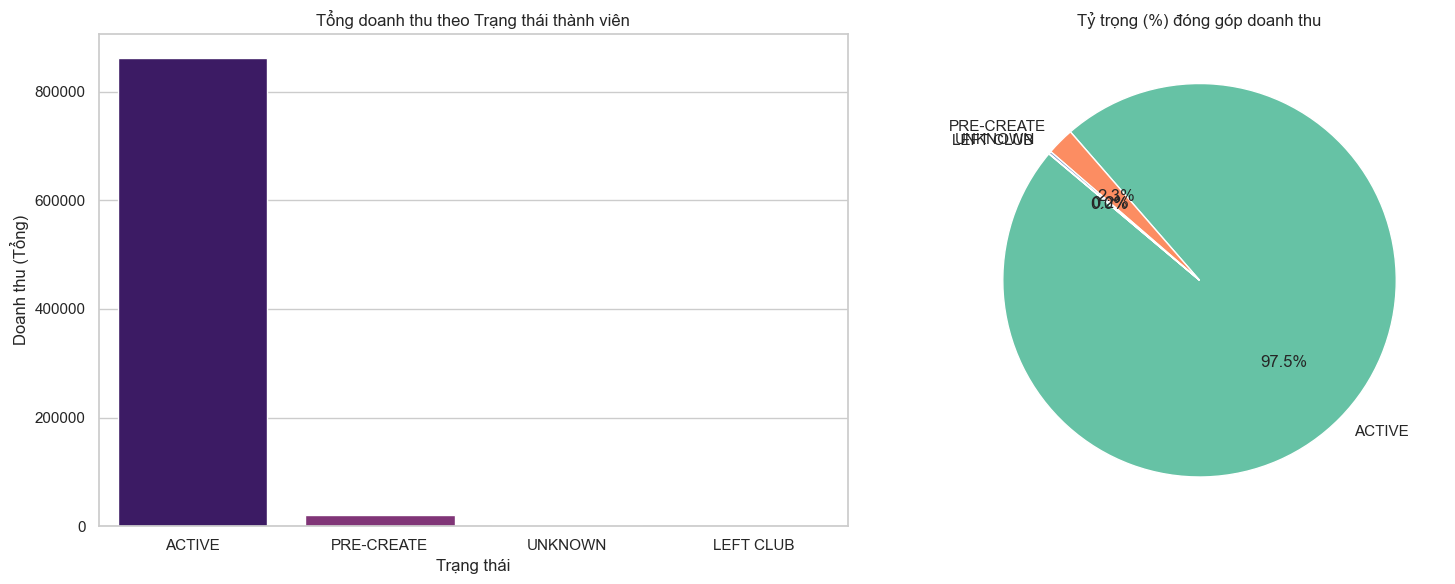

C:\Users\Dienbeotesting\AppData\Local\Temp\ipykernel_17404\2839236023.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf, x="club_member_status", y="avg_spending_per_customer", palette="viridis")


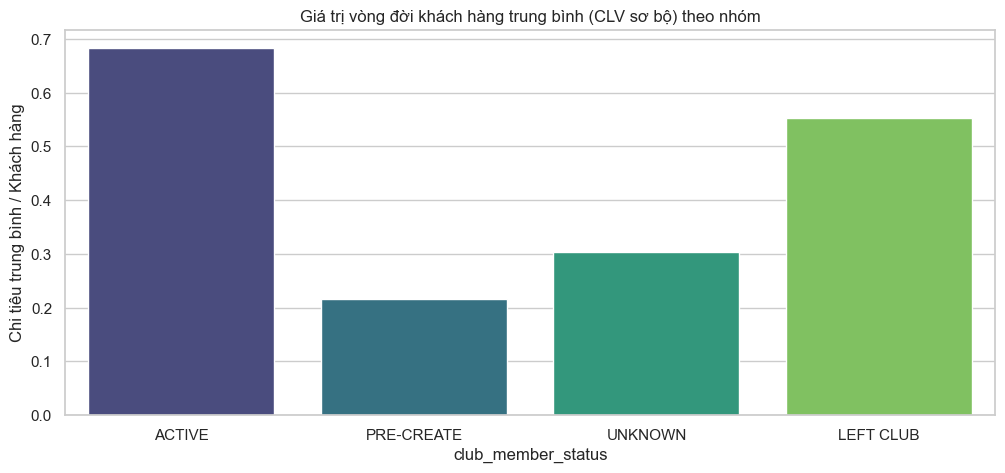

Pipeline hoàn tất thành công!


In [27]:


    # =========================
    # 8) MAIN EXECUTION (SỬA LỖI & TỐI ƯU)
    # =========================

    def build_member_status_stats(tx_lf: pl.LazyFrame, customers_df: pl.DataFrame) -> pl.DataFrame:
        """
        Tính toán thống kê theo trạng thái thành viên.
        SỬA: Sử dụng inner join để đảm bảo dữ liệu chính xác và đồng nhất.
        """
        # Chuyển customers_df sang Lazy để join tối ưu
        customers_lf = customers_df.lazy().select(["customer_id", "club_member_status"])

        member_stats = (
            tx_lf.join(customers_lf, on="customer_id", how="inner")
            .with_columns([
                pl.col("club_member_status").fill_null("UNKNOWN").alias("club_member_status")
            ])
            .group_by("club_member_status")
            .agg([
                pl.len().alias("num_transactions"),
                pl.col("price").sum().alias("total_spending"),
                pl.col("price").mean().alias("avg_order_value"),
                pl.col("customer_id").n_unique().alias("num_customers"),
            ])
            .with_columns([
                (pl.col("num_transactions") / pl.col("num_customers")).alias("avg_transactions_per_customer"),
                (pl.col("total_spending") / pl.col("num_customers")).alias("avg_spending_per_customer"),
            ])
            .sort("num_transactions", descending=True)
            .collect()
        )
        return member_stats

    def run_full_pipeline() -> None:
        print("Bắt đầu chạy Full Pipeline...")
        HMConfig.OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

        # 1. Ingestion & Light Parquet
        tx_lf = scan_transactions_lazy(HMConfig.TRANSACTIONS_CSV)
        build_transaction_light_parquet(HMConfig.TRANSACTIONS_CSV, HMConfig.OUTPUT_DIR / "transactions_light.parquet")

        # 2. Subset 6 tháng để test nhanh
        recent_df = save_recent_months_subset(tx_lf, months_back=6)
        print(f"Recent subset created. Shape: {recent_df.shape}")

        # 3. Cleaning danh mục
        customers_df = clean_customers(HMConfig.CUSTOMERS_CSV)
        articles_df = clean_articles(HMConfig.ARTICLES_CSV)
        articles_lf = articles_df.lazy()

        # 4. Product EDA
        print("Đang thực hiện Product EDA...")
        top_rev = top_100_products(tx_lf, articles_lf, metric="revenue")
        plot_monthly_revenue(tx_lf)
        plot_index_group_revenue(tx_lf, articles_df)

        # 5. RFM & Clustering Preparation
        print("Đang xây dựng RFM và tiền xử lý cho K-Means...")
        rfm_df = build_rfm(tx_lf, months_back=8)

        # GIẢI QUYẾT TODO: Kiểm tra tính nhất quán (Data Integrity)
        # Lọc bỏ khách hàng không có trong bảng customers sạch
        clean_cust_ids = customers_df.select("customer_id")
        rfm_df = rfm_df.join(clean_cust_ids, on="customer_id", how="inner")

        # Tiền xử lý (Log + Scale)
        rfm_pd, X_scaled = prepare_rfm_for_clustering(rfm_df)

        # 6. Customer EDA & Stats
        print("👥 Đang thực hiện Customer EDA...")
        plot_age_distribution(customers_df)

        # Vẽ biểu đồ RFM Before/After Log (Đã dời từ hàm stats lên đây)
        plot_rfm_before_after_log(rfm_pd)

        # Thống kê Membership
        m_stats = build_member_status_stats(tx_lf, customers_df)
        plot_customer_membership_eda(tx_lf, customers_df)

        print("Pipeline hoàn tất thành công!")

    if __name__ == "__main__":
        run_full_pipeline()

In [28]:
from __future__ import annotations
import os
from pathlib import Path
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện quan trọng 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Optional: pip install yellowbrick (giúp vẽ Elbow đẹp hơn)
try:
    from yellowbrick.cluster import KElbowVisualizer
except ImportError:
    print("Cài đặt 'pip install yellowbrick' để vẽ biểu đồ Elbow chuyên nghiệp hơn.")








Cài đặt 'pip install yellowbrick' để vẽ biểu đồ Elbow chuyên nghiệp hơn.


In [29]:
#1. Cấu hình chung cho dự án
class HMConfig:
    # Nếu chạy trên Colab thì giữ nguyên, nếu chạy PyCharm thì sửa đường dẫn này
    DRIVE_PATH = Path("")

    # Thư mục chứa kết quả của Tuần 1
    OUTPUT_DIR = Path("./outputs")

    # Các file dữ liệu sạch đã tạo từ Tuần 1
    RFM_CLEAN_PATH = OUTPUT_DIR / "customer_rfm_clean.parquet"
    CUSTOMERS_CLEAN_PATH = OUTPUT_DIR / "customers_clean.parquet"

    @classmethod
    def setup(cls):
        # Thiết lập hiển thị biểu đồ
        plt.rcParams["figure.figsize"] = (12, 6)
        sns.set_theme(style="whitegrid")

        if not cls.OUTPUT_DIR.exists():
            print(f"Cảnh báo: Không tìm thấy thư mục {cls.OUTPUT_DIR}. Hãy đảm bảo bạn đã chạy code Tuần 1!")
            # Khởi tạo cấu hình
HMConfig.setup()

In [30]:

#2. Nạp dữ liệu và tiền xử lý
def load_and_preprocess_data() -> Tuple[pd.DataFrame, np.ndarray]:
    """
    Nạp dữ liệu RFM và thực hiện các bước biến đổi toán học.
    """
    print("--- Đang nạp dữ liệu RFM từ Tuần 1 ---")

    # 1. Đọc file Parquet bằng Polars để tối ưu tốc độ
    if not HMConfig.RFM_CLEAN_PATH.exists():
        raise FileNotFoundError(f"Không tìm thấy file tại {HMConfig.RFM_CLEAN_PATH}. Hãy chạy lại Tuần 1!")

    rfm_df = pl.read_parquet(HMConfig.RFM_CLEAN_PATH)

    # Chuyển sang Pandas để tương thích với Scikit-learn
    rfm_pd = rfm_df.to_pandas().copy()

    # 2. Log Transformation (np.log1p)
    # Giúp đưa dữ liệu bị lệch về phân phối chuẩn hơn
    print("--- Thực hiện Log Transformation cho R, F, M ---")
    for col in ['recency', 'frequency', 'monetary']:
        rfm_pd[f"{col}_log"] = np.log1p(rfm_pd[col])

    # 3. Chuẩn hóa StandardScaler
    # Đưa dữ liệu về giá trị trung bình = 0 và độ lệch chuẩn = 1
    print("--- Chuẩn hóa dữ liệu bằng StandardScaler ---")
    features_log = ['recency_log', 'frequency_log', 'monetary_log']
    X_log = rfm_pd[features_log]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_log)

    # Lưu lại giá trị đã scale vào DataFrame để vẽ biểu đồ sau này
    rfm_pd[['recency_scaled', 'frequency_scaled', 'monetary_scaled']] = X_scaled

    print(f"Đã nạp và tiền xử lý xong cho {rfm_pd.shape[0]} khách hàng.")
    return rfm_pd, X_scaled

# --- Thực thi thử nghiệm ---
# rfm_pd, X_scaled = load_and_preprocess_data() (Chỉ chạy để kiểm tra)

In [31]:
#3. Tìm số cụm K tối ưu
def find_optimal_k(X_scaled: np.ndarray, max_k: int = 10):
    """
    Sử dụng Elbow Method (Phương pháp Khuỷu tay) để xác định số cụm K.
    Đầu vào: X_scaled (Dữ liệu đã chuẩn hóa từ Bước 2).
    """
    print(f"--- Đang chạy Elbow Method với K từ 1 đến {max_k} ---")

    # Tính WCSS (Tổng bình phương khoảng cách trong cụm)
    wcss = []
    for i in range(1, max_k + 1):
        # n_init=10: Chạy 10 lần với các tâm cụm ngẫu nhiên để chọn kết quả tốt nhất
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_) # inertia_ chính là WCSS

    # Vẽ biểu đồ Elbow
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--', color='b')

    # Chú thích điểm gãy (Thường K tối ưu nằm ở nơi đường cong bắt đầu phẳng đi)
    plt.title('Biểu đồ Elbow Method để chọn K tối ưu', fontsize=14)
    plt.xlabel('Số lượng cụm (K)')
    plt.ylabel('WCSS (Inertia)')
    plt.xticks(range(1, max_k + 1))
    plt.grid(True, alpha=0.3)

    # Lưu biểu đồ vào thư mục outputs để đưa vào báo cáo
    plt.savefig(HMConfig.OUTPUT_DIR / "elbow_method_plot.png")
    plt.show()

    print(f"Biểu đồ Elbow đã được lưu tại {HMConfig.OUTPUT_DIR}")


In [32]:

#4. Thực thi K-Means & Gán nhãn cụm
def perform_kmeans_clustering(rfm_pd: pd.DataFrame, X_scaled: np.ndarray, k: int) -> pd.DataFrame:
    """
    Thực hiện phân cụm K-Means với số cụm k tối ưu.
    """
    print(f"--- Đang thực thi K-Means với K = {k} ---")

    # 1. Khởi tạo và huấn luyện mô hình
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    rfm_pd['Cluster'] = kmeans.fit_predict(X_scaled)

    # 2. Thống kê đặc trưng các cụm (Dùng giá trị thực để dễ hiểu)
    # Chúng ta xem trung bình Recency (ngày), Frequency (lần), Monetary (tiền)
    cluster_profile = rfm_pd.groupby('Cluster').agg({
        'recency': 'mean',
        'frequency': 'mean',
        'monetary': 'mean'
    }).sort_values(by='monetary', ascending=False) # Sắp xếp theo mức chi tiêu

    print("\n📊 BẢNG ĐẶC TRƯNG TRUNG BÌNH CÁC CỤM:")
    print(cluster_profile)

    # 3. Lưu bảng RFM đã phân cụm để dùng cho Tuần 3
    output_path = HMConfig.OUTPUT_DIR / "customer_segments_final.parquet"
    pl.from_pandas(rfm_pd).write_parquet(output_path)

    print(f"\n Đã lưu kết quả phân cụm tại: {output_path}")
    return rfm_pd


In [33]:

#5. Vẽ Snake Plot để giải mã hành vi
def plot_snake_plot(rfm_pd: pd.DataFrame):
    """
    Vẽ Snake Plot để so sánh đặc trưng R-F-M giữa các cụm.
    Sử dụng dữ liệu đã chuẩn hóa (scaled) để các đường nằm trên cùng một thang đo.
    """
    print("--- Đang vẽ Snake Plot để giải mã đặc trưng các cụm ---")

    # 1. Chuẩn bị dữ liệu dạng "Long format" để Seaborn dễ xử lý
    # Chỉ lấy các cột đã scale và nhãn Cluster
    features_scaled = ['recency_scaled', 'frequency_scaled', 'monetary_scaled']

    # Chuyển bảng từ dạng ngang sang dạng dọc
    df_melt = pd.melt(
        rfm_pd.reset_index(),
        id_vars=['Cluster'],
        value_vars=features_scaled,
        var_name='Metric',
        value_name='Value'
    )

    # Đổi tên Metric cho đẹp trên biểu đồ
    df_melt['Metric'] = df_melt['Metric'].replace({
        'recency_scaled': 'Recency',
        'frequency_scaled': 'Frequency',
        'monetary_scaled': 'Monetary'
    })

    # 2. Vẽ biểu đồ đường (Line Plot)
    plt.figure(figsize=(12, 7))
    sns.lineplot(data=df_melt, x='Metric', y='Value', hue='Cluster', palette='bright', marker='o', linewidth=2)

    plt.title('Snake Plot: So sánh đặc trưng RFM giữa các cụm khách hàng', fontsize=15)
    plt.xlabel('Chỉ số RFM', fontsize=12)
    plt.ylabel('Giá trị đã chuẩn hóa (Z-Score)', fontsize=12)
    plt.legend(title='Cụm', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Lưu biểu đồ
    plt.savefig(HMConfig.OUTPUT_DIR / "rfm_snake_plot.png")
    plt.show()

    print(f" Biểu đồ Snake Plot đã được lưu tại {HMConfig.OUTPUT_DIR}")

In [34]:

#6. Phân tích Nhân khẩu học theo cụm
def analyze_cluster_demographics(rfm_pd: pd.DataFrame):
    """
    Hợp nhất nhãn cụm với thông tin tuổi và trạng thái thành viên.
    """
    print("--- Đang phân tích đặc điểm nhân khẩu học theo từng cụm ---")

    # 1. Nạp lại bảng khách hàng sạch từ Tuần 1
    if not HMConfig.CUSTOMERS_CLEAN_PATH.exists():
        print("Cảnh báo: Không tìm thấy file khách hàng sạch. Bỏ qua bước này.")
        return

    customers_clean = pl.read_parquet(HMConfig.CUSTOMERS_CLEAN_PATH)

    # 2. Hợp nhất (Merge) nhãn cụm vào thông tin khách hàng
    # rfm_pd đang ở dạng Pandas, ta chuyển sang Polars để join cho nhanh
    final_df = (
        pl.from_pandas(rfm_pd)
        .join(customers_clean, on="customer_id", how="inner")
    ).collect_schema() # Kiểm tra schema

    final_df = pl.from_pandas(rfm_pd).join(customers_clean, on="customer_id", how="inner")

    # 3. Thống kê độ tuổi và Membership theo Cụm
    # Chuyển về Pandas để dùng groupby tiện lợi cho việc in ấn
    final_pd = final_df.to_pandas()

    demo_stats = final_pd.groupby('Cluster').agg({
        'age': 'mean',
        'club_member_status': lambda x: x.value_counts().index[0] # Trạng thái phổ biến nhất
    }).rename(columns={'age': 'Độ tuổi trung bình', 'club_member_status': 'Membership phổ biến'})

    print("\n👥 ĐẶC ĐIỂM NHÂN KHẨU HỌC:")
    print(demo_stats)

    # 4. Vẽ biểu đồ phân phối tuổi theo cụm
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=final_pd, x='Cluster', y='age', palette='Set3')
    plt.title('Phân phối độ tuổi theo từng cụm khách hàng', fontsize=14)
    plt.grid(axis='y', alpha=0.3)

    plt.savefig(HMConfig.OUTPUT_DIR / "cluster_age_distribution.png")
    plt.show()

    return final_pd

--- Đang nạp dữ liệu RFM từ Tuần 1 ---
--- Thực hiện Log Transformation cho R, F, M ---
--- Chuẩn hóa dữ liệu bằng StandardScaler ---
Đã nạp và tiền xử lý xong cho 837609 khách hàng.
--- Đang thực thi K-Means với K = 4 ---

📊 BẢNG ĐẶC TRƯNG TRUNG BÌNH CÁC CỤM:
            recency  frequency  monetary
Cluster                                 
2         23.364292  46.921834  1.350367
3         76.556920  14.590705  0.368851
1         11.435053   8.796883  0.231753
0        124.955691   3.242100  0.083679

 Đã lưu kết quả phân cụm tại: outputs\customer_segments_final.parquet
--- Đang vẽ Snake Plot để giải mã đặc trưng các cụm ---


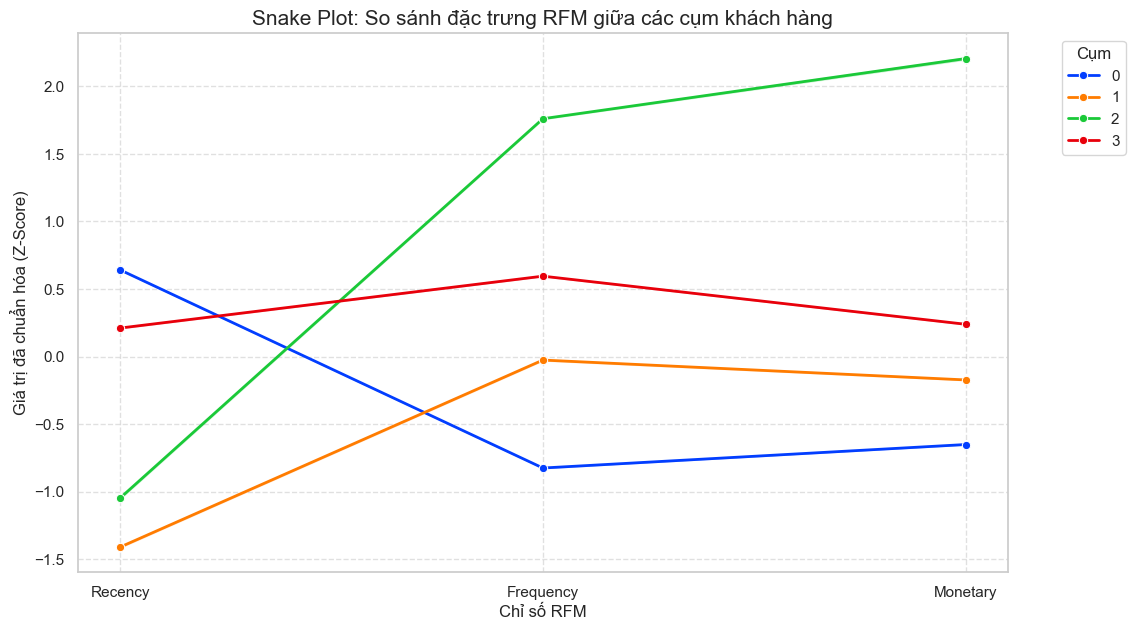

 Biểu đồ Snake Plot đã được lưu tại outputs
--- Đang phân tích đặc điểm nhân khẩu học theo từng cụm ---

👥 ĐẶC ĐIỂM NHÂN KHẨU HỌC:
         Độ tuổi trung bình Membership phổ biến
Cluster                                        
0                 35.616707              ACTIVE
1                 35.144238              ACTIVE
2                 35.670647              ACTIVE
3                 34.869179              ACTIVE


C:\Users\Dienbeotesting\AppData\Local\Temp\ipykernel_17404\2174639992.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_pd, x='Cluster', y='age', palette='Set3')


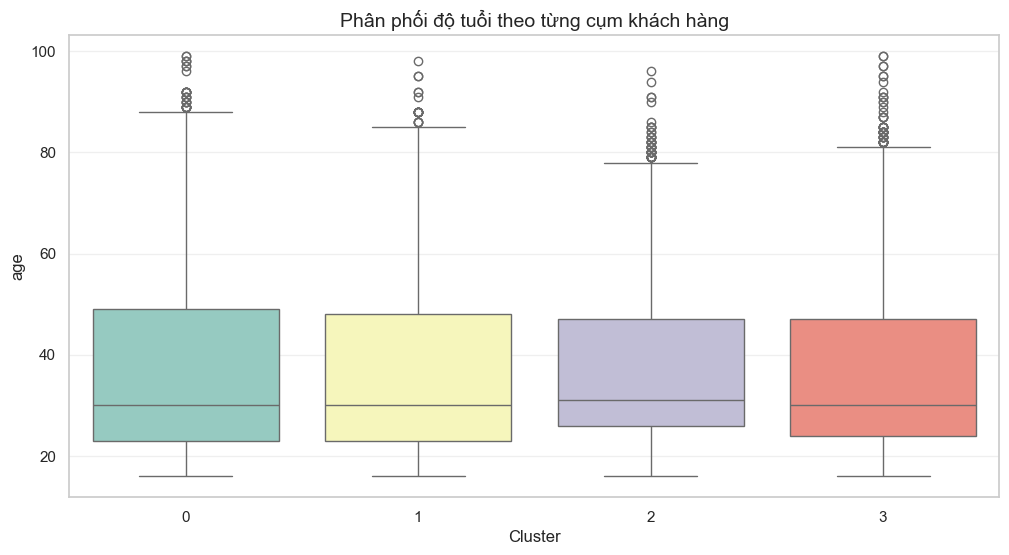

In [35]:

#7. Hàm thực thi chính
if __name__ == "__main__":
    # Bước 1: Nạp và tiền xử lý
    rfm_pd, X_scaled = load_and_preprocess_data()

    # Bước 2: Chạy Elbow để tìm K (Bạn chạy lần đầu, xem hình rồi chọn K)
    #find_optimal_k(X_scaled)
#Biểu đồ Elbow cho thấy WCSS giảm mạnh từ K=1 đến K=4, sau đó giảm chậm dần. Điều này cho thấy việc tăng số cụm sau K=4 #không mang lại nhiều cải thiện, vì vậy chúng tôi chọn K=4 là số cụm tối ưu
    # Bước 3: Sau khi chọn được K (ví dụ K=4), comment dòng Elbow và chạy dòng dưới
    K_OPTIMAL = 4
    rfm_clustered = perform_kmeans_clustering(rfm_pd, X_scaled, k=K_OPTIMAL)

    # Bước 4: Vẽ biểu đồ giải mã (Snake Plot)
    plot_snake_plot(rfm_clustered)

    # Bước 5: Phân tích nhân khẩu học
    final_data = analyze_cluster_demographics(rfm_clustered)

In [36]:
#---1. Khai báo & thiết lập hệ thống---
from __future__ import annotations
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Thư viện thuật toán Association Rules
try:
    from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
except ImportError:
    # Gợi ý cài đặt nếu thiếu
    print("Thiếu mlxtend. Đang cố gắng cài đặt hoặc hãy chạy: pip install mlxtend")
    raise ImportError("Thiếu mlxtend.")

# --- CẤU HÌNH HIỂN THỊ & HIỆU NĂNG ---
plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid")

# Cấu hình Polars để xem dữ liệu lớn dễ dàng hơn
pl.Config.set_tbl_rows(15)
pl.Config.set_tbl_cols(15)
pl.Config.set_fmt_str_lengths(50) # Không cắt ngắn ID khách hàng quá nhiều

class W3Config:
    # 1. Tự động xác định BASE_DIR để tránh lỗi khi chạy ở các thư mục khác nhau
    BASE_DIR = Path(".").resolve()
    OUTPUT_DIR = BASE_DIR / "outputs"

    # 2. Các file dữ liệu nguồn (Đầu vào)
    TRANSACTIONS_CSV  = BASE_DIR / "transactions_train.csv"
    CUSTOMERS_CLEAN   = OUTPUT_DIR / "customers_clean.parquet"
    ARTICLES_CLEAN    = OUTPUT_DIR / "articles_clean.parquet"
    CUSTOMER_SEGMENTS = OUTPUT_DIR / "customer_segments_final.parquet"

    # 3. Các file kết quả Tuần 3 (Đầu ra)
    BASKETS_PARQUET              = OUTPUT_DIR / "transaction_baskets.parquet"
    CHAMPION_RULES_PARQUET       = OUTPUT_DIR / "champion_association_rules.parquet"
    CLUSTER_TOP_PRODUCTS_PARQUET = OUTPUT_DIR / "cluster_top_products.parquet"
    RECOMMENDATIONS_PARQUET      = OUTPUT_DIR / "customer_recommendations.parquet"

    @classmethod
    def setup(cls):
        """Tạo thư mục và kiểm tra file nguồn để tránh lỗi giữa chừng."""
        cls.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

        # Kiểm tra xem các file từ Tuần 1 & 2 đã tồn tại chưa
        inputs = [cls.CUSTOMERS_CLEAN, cls.ARTICLES_CLEAN, cls.CUSTOMER_SEGMENTS]
        for f in inputs:
            if not f.exists():
                print(f"Cảnh báo: Không tìm thấy {f.name} tại {f.parent}. "
                      f"Hãy đảm bảo đã có kết quả tuần 1 & 2 vào thư mục outputs!")

# Thực thi cấu hình
W3Config.setup()

In [37]:

#---2. Nạp dữ liệu đầu vào---

# Quét giao dịch (Lazy): Chỉ lấy những cột thực sự cần cho Basket & Rules. Việc loại bỏ các cột không dùng (như sales_channel_id) giúp tiết kiệm rất nhiều RAM
transactions_lf = (
    pl.scan_csv(
        W3Config.TRANSACTIONS_CSV,
        schema_overrides={
            "customer_id": pl.Utf8,
            "article_id": pl.Int32,
            "price": pl.Float32,
        },
        try_parse_dates=True,
        infer_schema_length=10000,
        low_memory=True,
    )
    .select(["t_dat", "customer_id", "article_id", "price"]) # Chỉ lấy cột cần thiết
    .with_columns([
        pl.col("t_dat").cast(pl.Date, strict=False),
        pl.col("customer_id").str.strip_chars(), # Đảm bảo không có khoảng trắng thừa gây lỗi join
    ])
)

# Nạp các bảng Parquet sạch (Đã đồng nhất kiểu dữ liệu với Transactions). Ép kiểu String (Utf8) ngay từ đầu để các phép Join sau này không bị lệch Schema
customers_clean = pl.read_parquet(W3Config.CUSTOMERS_CLEAN).select(["customer_id", "club_member_status"])

articles_clean = pl.read_parquet(W3Config.ARTICLES_CLEAN).select(["article_id", "prod_name", "product_group_name"])

segments = pl.read_parquet(W3Config.CUSTOMER_SEGMENTS).with_columns([
    pl.col("customer_id").cast(pl.Utf8).str.strip_chars(),
    pl.col("Cluster").cast(pl.Int8) # Ép kiểu Int8 cho Cluster để tiết kiệm bộ nhớ
])

print(f" Đã nạp xong: {customers_clean.height:,} Customers, {articles_clean.height:,} Articles.")
print(f" Đã nạp bảng Segments: {segments.height:,} khách hàng phân cụm.")

display(segments.head())

 Đã nạp xong: 1,371,980 Customers, 105,542 Articles.
 Đã nạp bảng Segments: 837,609 khách hàng phân cụm.


customer_id,recency,frequency,monetary,recency_log,frequency_log,monetary_log,recency_scaled,frequency_scaled,monetary_scaled,Cluster
str,i64,u32,f32,f64,f64,f32,f64,f64,f64,i8
"""be060c0eeec96095c66b04b2f796f29daae19bc16a645ff39d…",143,2,0.055898,4.969813,1.098612,0.054392,0.88085,-1.092486,-0.748618,0
"""654235656a0f90152bbc2b5c046e35a79a129291f335b5a833…",37,7,0.099203,3.637586,2.079442,0.094586,-0.234521,-0.039286,-0.591125,3
"""197ccf7e20bb9a5475982623e41a2a0481e1e90b5b39a7b20d…",0,4,0.110102,0.0,1.609438,0.104452,-3.279992,-0.543969,-0.552467,1
"""e2df08626151f68ddf5ce67502dff9bc03b12788aceae6f3cf…",184,3,0.040746,5.220356,1.386294,0.039938,1.09061,-0.783577,-0.805255,0
"""1492593f59c2296451f03069685aac7d170c4f31ae67de8943…",38,14,0.294678,3.663562,2.70805,0.258262,-0.212774,0.635705,0.050216,3


In [38]:

#---3. Kiểm tra và Chuẩn hóa Schema Segmentation---

# Danh sách cột bắt buộc phải có từ Tuần 2
required_cols = ["customer_id", "Cluster", "recency", "frequency", "monetary"]
missing_cols = [c for c in required_cols if c not in segments.columns]

if missing_cols:
    raise ValueError(f" Lỗi: File segmentation thiếu các cột: {missing_cols}. Hãy kiểm tra lại kết quả Tuần 2!")

# Tối ưu: Ép kiểu dữ liệu đồng nhất để tránh lỗi Join Keys mismatch
# Ép customer_id về String và Cluster về Int để tiết kiệm RAM
segments = segments.select(required_cols).with_columns([
    pl.col("customer_id").cast(pl.Utf8).str.strip_chars(),
    pl.col("Cluster").cast(pl.Int8),
    pl.col("recency").cast(pl.Int32),
    pl.col("frequency").cast(pl.Int32),
    pl.col("monetary").cast(pl.Float32),
])

print(f" Schema hợp lệ. Đang xử lý {segments.height:,} khách hàng đã phân cụm.")
display(segments.head())


 Schema hợp lệ. Đang xử lý 837,609 khách hàng đã phân cụm.


customer_id,Cluster,recency,frequency,monetary
str,i8,i32,i32,f32
"""be060c0eeec96095c66b04b2f796f29daae19bc16a645ff39d…",0,143,2,0.055898
"""654235656a0f90152bbc2b5c046e35a79a129291f335b5a833…",3,37,7,0.099203
"""197ccf7e20bb9a5475982623e41a2a0481e1e90b5b39a7b20d…",1,0,4,0.110102
"""e2df08626151f68ddf5ce67502dff9bc03b12788aceae6f3cf…",0,184,3,0.040746
"""1492593f59c2296451f03069685aac7d170c4f31ae67de8943…",3,38,14,0.294678


In [39]:


#---4. Gán tên hành vi cho từng cụm---
# Tính toán Profile cho từng cụm để nhận diện nhãn
cluster_profile = (
    segments.group_by("Cluster")
    .agg([
        pl.col("recency").mean().alias("avg_recency"),
        pl.col("frequency").mean().alias("avg_frequency"),
        pl.col("monetary").mean().alias("avg_monetary"),
        pl.len().alias("num_customers")
    ])
    .sort("Cluster")
)

# Chuyển sang Pandas để xử lý logic định danh persona
profile_pd = cluster_profile.to_pandas()

# Thuật toán tự động nhận diện ID của từng nhóm
# Nhóm Champions: Mua gần đây nhất (recency min) và tiêu nhiều nhất
champion_id = profile_pd.sort_values(
    ["avg_recency", "avg_monetary"], ascending=[True, False]
).iloc[0]["Cluster"]

# Nhóm Hibernating: Đã lâu nhất chưa quay lại (recency max)
hibernating_id = profile_pd.sort_values(
    "avg_recency", ascending=False
).iloc[0]["Cluster"]

# Nhóm New Customers: Mới mua (recency thấp) nhưng tần suất mua ít
# Lọc bỏ 2 nhóm trên trước khi tìm
remaining = profile_pd[~profile_pd["Cluster"].isin([champion_id, hibernating_id])]
new_cust_id = remaining.sort_values(
    ["avg_recency", "avg_frequency"], ascending=[True, True]
).iloc[0]["Cluster"]

# Tạo Mapping Dictionary từ kết quả tính toán
# Các cụm còn lại mặc định là Loyalists
cluster_name_map = {c: "Loyalists" for c in profile_pd["Cluster"]}
cluster_name_map[champion_id] = "Champions"
cluster_name_map[hibernating_id] = "Hibernating"
cluster_name_map[new_cust_id] = "New Customers"

print(" Kết quả nhận diện cụm tự động:", cluster_name_map)

# Áp dụng nhãn vào bảng Segments bằng phép Join thay vì gán cứng
mapping_df = pl.DataFrame({
    "Cluster": list(cluster_name_map.keys()),
    "Cluster_Name": list(cluster_name_map.values())
}).with_columns(pl.col("Cluster").cast(pl.Int8))

segments_named = segments.join(mapping_df, on="Cluster", how="left")

# Kiểm tra kết quả
display(segments_named.group_by("Cluster_Name").agg(pl.len()).sort("len", descending=True))


 Kết quả nhận diện cụm tự động: {0: 'Hibernating', 1: 'Champions', 2: 'New Customers', 3: 'Loyalists'}


Cluster_Name,len
str,u32
"""Hibernating""",368662
"""Loyalists""",241320
"""Champions""",134287
"""New Customers""",93340


In [40]:


#---5. Join transactions với segmentation (Tối ưu bộ nhớ)---


# Chuyển bảng segments_named sang Lazy để tối ưu hóa kế hoạch thực thi (Query Plan)
segments_lazy = segments_named.lazy().select(["customer_id", "Cluster", "Cluster_Name"])

# Thực hiện phép Join: Sử dụng LazyFrame giúp Polars chỉ nạp những dữ liệu cần thiết vào RAM khi gọi .collect()
tx_cluster_lf = (
    transactions_lf
    .join(
        segments_lazy,
        on="customer_id",
        how="inner"
    )
    # Loại bỏ các dòng có giá trị Null nếu khách hàng không nằm trong danh sách phân cụm
    .drop_nulls(subset=["Cluster_Name"])
)

# Kiểm tra kết quả (Chỉ lấy 5 dòng để xem nhanh, tránh load toàn bộ)
print("--- Xem trước dữ liệu sau khi Join ---")
display(
    tx_cluster_lf.select([
        "customer_id", "t_dat", "article_id", "price", "Cluster_Name"
    ])
    .limit(5)
    .collect()
)

# Kiểm tra phân bổ giao dịch theo từng cụm (Quan trọng để kiểm tra tính logic)
print("\n--- Thống kê số lượng giao dịch theo cụm ---")
display(
    tx_cluster_lf.group_by("Cluster_Name")
    .agg(pl.len().alias("transaction_count"))
    .collect()
)

--- Xem trước dữ liệu sau khi Join ---


customer_id,t_dat,article_id,price,Cluster_Name
str,date,i32,f32,str
"""000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ff…",2018-09-20,663713001,0.050831,"""Champions"""
"""000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ff…",2018-09-20,541518023,0.030492,"""Champions"""
"""00007d2de826758b65a93dd24ce629ed66842531df6699338c…",2018-09-20,505221004,0.015237,"""Loyalists"""
"""00007d2de826758b65a93dd24ce629ed66842531df6699338c…",2018-09-20,685687003,0.016932,"""Loyalists"""
"""00007d2de826758b65a93dd24ce629ed66842531df6699338c…",2018-09-20,685687004,0.016932,"""Loyalists"""



--- Thống kê số lượng giao dịch theo cụm ---


Cluster_Name,transaction_count
str,u32
"""Champions""",3394368
"""Hibernating""",4341706
"""Loyalists""",9189474
"""New Customers""",10759391


In [41]:


#---6. Xây dựng transaction basket (Tối ưu Streaming & Memory) ---

# Định nghĩa logic gom nhóm giỏ hàng: Sử dụng LazyFrame để tối ưu hóa việc đọc/ghi
baskets_lf = (
    tx_cluster_lf
    .group_by(["customer_id", "t_dat", "Cluster_Name"])
    .agg([
        # Lấy danh sách article_id duy nhất trong cùng 1 ngày của 1 khách
        pl.col("article_id").unique().alias("basket_articles"),
        # Tính quy mô giỏ hàng
        pl.len().alias("basket_size"),
        # Tổng giá trị giỏ hàng
        pl.col("price").sum().alias("basket_value")
    ])
    # TỐI ƯU: Chỉ giữ lại các giỏ hàng có từ 2 sản phẩm trở lên: Vì Association Rules (Apriori) không thể tìm luật từ giỏ hàng chỉ có 1 món
    .filter(pl.col("basket_size") >= 2)
)

# Thực thi với chế độ STREAMING: Chế độ này giúp Polars xử lý dữ liệu theo từng phần, không nạp tất cả vào RAM cùng lúc
print("--- Đang xây dựng giỏ hàng (Chế độ Streaming)... ---")
baskets = baskets_lf.collect(streaming=True)

print(f"Đã tạo xong {baskets.height:,} giỏ hàng chất lượng (size >= 2).")
display(baskets.head())

# Lưu kết quả
baskets.write_parquet(W3Config.BASKETS_PARQUET)
print(f"Đã lưu file basket tại: {W3Config.BASKETS_PARQUET}")

--- Đang xây dựng giỏ hàng (Chế độ Streaming)... ---


C:\Users\Dienbeotesting\AppData\Local\Temp\ipykernel_17404\3265766911.py:21: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  baskets = baskets_lf.collect(streaming=True)


Đã tạo xong 5,568,747 giỏ hàng chất lượng (size >= 2).


customer_id,t_dat,Cluster_Name,basket_articles,basket_size,basket_value
str,date,str,list[i32],u32,f32
"""3de1cf5ba41bf1404999ff96182cccb27debe13acaf16425d0…",2019-08-14,"""Hibernating""","[737260001, 747196004]",2,0.014203
"""45aaf505a445fc6f883046ddcb1e50551082eebfb3823fbffa…",2019-08-10,"""Champions""","[776861002, 717884004, 723912001]",3,0.084695
"""d8fe19346c8233ec92ca50b46f5ff3d1a49102aef88252e96b…",2019-10-18,"""Loyalists""","[736531009, 736530011]",2,0.035559
"""7710c23583dc2063ebd37639b4733e3dda32e4b6163a52f64f…",2020-09-06,"""New Customers""","[808025001, 682289012]",2,0.084712
"""5c2f428359ac9039785c45b1713024b334c5a98273eb00a585…",2019-05-18,"""New Customers""","[767605007, 745321001, 770857002]",4,0.179932


Đã lưu file basket tại: C:\Users\Dienbeotesting\PycharmProjects\PythonProject1\outputs\transaction_baskets.parquet


In [42]:


#---7 & 8. Lọc baskets Champions & Giảm chiều sản phẩm (Tối ưu Speed)---

# Lọc riêng baskets của Champions (Dùng lại biến baskets đã collect từ bước 6)
champion_baskets = baskets.filter(pl.col("Cluster_Name") == "Champions")
print(f"--- Số lượng giỏ hàng Champions ban đầu: {champion_baskets.height:,} ---")

# Tìm Top N sản phẩm phổ biến nhất trong nhóm Champions
TOP_N_RULE_PRODUCTS = 150

# Tối ưu: Tính tần suất sản phẩm nhanh bằng explode
champion_item_freq = (
    champion_baskets
    .select("basket_articles")
    .explode("basket_articles")
    .group_by("basket_articles")
    .agg(pl.len().alias("freq"))
    .sort("freq", descending=True)
)

top_rule_products = champion_item_freq.head(TOP_N_RULE_PRODUCTS)["basket_articles"].to_list()
top_rule_products_set = set(top_rule_products) # Dùng set để tìm kiếm nhanh hơn O(1)

# Lọc giỏ hàng: Chỉ giữ lại các sản phẩm nằm trong Top N
# Tối ưu logic: Loại bỏ các sản phẩm "nhiễu" khỏi giỏ hàng
champion_baskets_filtered = (
    champion_baskets
    .with_columns([
        pl.col("basket_articles")
        .list.eval(pl.element().filter(pl.element().is_in(top_rule_products)))
        .alias("basket_articles")
    ])
    .with_columns([
        pl.col("basket_articles").list.len().alias("filtered_basket_size")
    ])
    # Quan trọng: Sau khi lọc sản phẩm nhiễu, giỏ hàng phải còn ít nhất 2 món mới dùng được
    .filter(pl.col("filtered_basket_size") >= 2)
    .drop("filtered_basket_size")
)

print(f" Số lượng giỏ hàng Champions sau khi lọc Top {TOP_N_RULE_PRODUCTS}: {champion_baskets_filtered.height:,}")
display(champion_baskets_filtered.head())

--- Số lượng giỏ hàng Champions ban đầu: 799,415 ---
 Số lượng giỏ hàng Champions sau khi lọc Top 150: 26,714


customer_id,t_dat,Cluster_Name,basket_articles,basket_size,basket_value
str,date,str,list[i32],u32,f32
"""fbc5e76c470be413a085914406422575c449a67f0d338ca23a…",2019-12-04,"""Champions""","[772902001, 372860001, 537116001]",5,0.084661
"""90e8f21dd7820011c2ce8e07a2cec32dc7a1a81a80bcd65923…",2019-06-24,"""Champions""","[688537011, 684209013]",3,0.059271
"""3aa03200962c8d6c7be26622ad75010ec3333278d99e47bbfc…",2019-12-24,"""Champions""","[436261001, 111593001]",3,0.033915
"""51fb789b91367259ae6adc3ca2272df76970cb112bfeaad0c0…",2020-04-14,"""Champions""","[716672001, 759465001]",5,0.113475
"""abb8a360b1fd44d33337a8c76526c09b5ed2f8244bc60b1bb2…",2020-09-03,"""Champions""","[562245046, 673396002]",3,0.115203


In [43]:


#---9 & 10. One-hot Matrix & Association Rules (Tối ưu bộ nhớ & Tốc độ)---

from mlxtend.preprocessing import TransactionEncoder

# Chuyển đổi dữ liệu sang định dạng One-hot Matrix
# Tối ưu: TransactionEncoder nhanh hơn và ít tốn RAM hơn việc tạo DataFrame bằng Dictionary
te = TransactionEncoder()
print("--- Đang mã hóa giỏ hàng sang ma trận One-hot... ---")

# Lấy danh sách các giỏ hàng (list of lists)
dataset = champion_baskets_filtered["basket_articles"].to_list()

# Encode và chuyển về DataFrame (Sparse format nếu cần)
te_ary = te.fit(dataset).transform(dataset)
basket_matrix = pd.DataFrame(te_ary, columns=te.columns_)

print(f" Ma trận One-hot hoàn tất. Kích thước: {basket_matrix.shape}")

# Chạy thuật toán tìm tập mục phổ biến (Frequent Itemsets)
# MẸO: Nếu Apriori vẫn chậm, bạn có thể thay bằng fpgrowth (nhanh hơn rất nhiều)
MIN_SUPPORT = 0.003

print(f"--- Đang tìm tập mục phổ biến (Min Support: {MIN_SUPPORT})... ---")
frequent_itemsets = apriori(
    basket_matrix,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    low_memory=True # Tiết kiệm RAM khi tính toán
)

# Tạo luật kết hợp (Association Rules)
MIN_CONFIDENCE = 0.10
MIN_LIFT = 1.05

if not frequent_itemsets.empty:
    print(f"--- Đang trích xuất luật kết hợp (Min Conf: {MIN_CONFIDENCE})... ---")
    rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=MIN_CONFIDENCE
    )

    # Lọc theo Lift và sắp xếp để lấy những luật mạnh nhất
    rules = rules[rules["lift"] >= MIN_LIFT].copy()
    rules = rules.sort_values(["lift", "confidence"], ascending=False)

    print(f" Đã tìm thấy {len(rules)} luật kết hợp cho nhóm Champions.")
    display(rules.head(10))
else:
    print(" Không tìm thấy tập mục nào thỏa mãn Min Support. Hãy thử giảm MIN_SUPPORT.")
    rules = pd.DataFrame()


--- Đang mã hóa giỏ hàng sang ma trận One-hot... ---
 Ma trận One-hot hoàn tất. Kích thước: (26714, 150)
--- Đang tìm tập mục phổ biến (Min Support: 0.003)... ---
--- Đang trích xuất luật kết hợp (Min Conf: 0.1)... ---
 Đã tìm thấy 106 luật kết hợp cho nhóm Champions.


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
27,(564786001),(484398001),0.007000,0.008423,0.003182,0.454545,53.967677,1.0,0.003123,1.817892,0.988389,0.259939,0.449912,0.416162
28,(484398001),(564786001),0.008423,0.007000,0.003182,0.377778,53.967677,1.0,0.003123,1.595893,0.989807,0.259939,0.373391,0.416162
29,(539723001),(539723005),0.008198,0.009733,0.003931,0.479452,49.261855,1.0,0.003851,1.902356,0.987798,0.280749,0.474336,0.441649
30,(539723005),(539723001),0.009733,0.008198,0.003931,0.403846,49.261855,1.0,0.003851,1.663668,0.989329,0.280749,0.398919,0.441649
67,(685816002),(685816001),0.014000,0.011866,0.007936,0.566845,47.768755,1.0,0.007770,2.281247,0.992968,0.442589,0.561643,0.617807
66,(685816001),(685816002),0.011866,0.014000,0.007936,0.668770,47.768755,1.0,0.007770,2.976781,0.990823,0.442589,0.664067,0.617807
34,(554479001),(554479005),0.011268,0.011268,0.005915,0.524917,46.586815,1.0,0.005788,2.081178,0.989686,0.355856,0.519503,0.524917
35,(554479005),(554479001),0.011268,0.011268,0.005915,0.524917,46.586815,1.0,0.005788,2.081178,0.989686,0.355856,0.519503,0.524917
92,(749699001),(749699002),0.012353,0.011380,0.006364,0.515152,45.268939,1.0,0.006223,2.039029,0.990141,0.366379,0.509571,0.537181
93,(749699002),(749699001),0.011380,0.012353,0.006364,0.559211,45.268939,1.0,0.006223,2.240632,0.989166,0.366379,0.553697,0.537181


TOP 10 LUẬT KẾT HỢP (DỰA TRÊN TÊN SẢN PHẨM):


,antecedents_name,consequents_name,support,confidence,lift
0,karin sports bra,supreme tights,0.003182,0.454545,53.967677
1,supreme tights,karin sports bra,0.003182,0.377778,53.967677
2,jade denim trs,jade denim trs,0.003931,0.479452,49.261855
3,jade denim trs,jade denim trs,0.003931,0.403846,49.261855
4,ronny reg rn t-shirt,ronny reg rn t-shirt,0.007936,0.566845,47.768755
5,ronny reg rn t-shirt,ronny reg rn t-shirt,0.007936,0.668770,47.768755
6,ozzy denim shorts,ozzy denim shorts,0.005915,0.524917,46.586815
7,ozzy denim shorts,ozzy denim shorts,0.005915,0.524917,46.586815
8,chestnut strap top,chestnut strap top,0.006364,0.515152,45.268939
9,chestnut strap top,chestnut strap top,0.006364,0.559211,45.268939


C:\Users\Dienbeotesting\AppData\Local\Temp\ipykernel_17404\4189074596.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_plot, x='confidence', y='rule_label', ax=axes[0], palette='viridis')
C:\Users\Dienbeotesting\AppData\Local\Temp\ipykernel_17404\4189074596.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_plot, x='lift', y='rule_label', ax=axes[1], palette='magma')


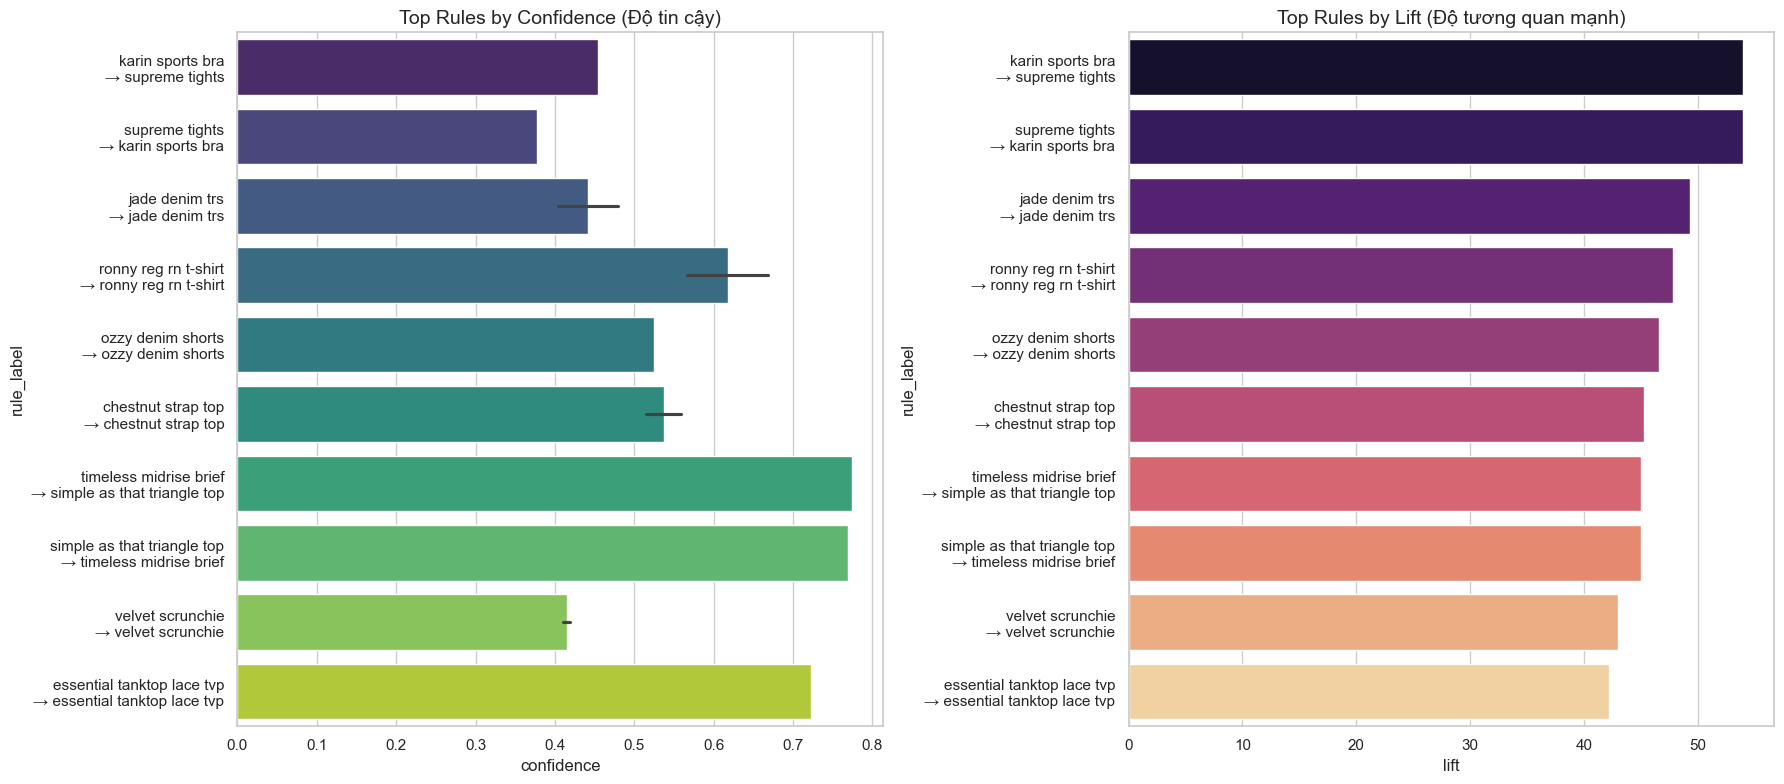

In [44]:


#---11 & 12. Làm đẹp & Trực quan hóa Luật kết hợp (Thêm tên sản phẩm)---

if len(rules) > 0:
    # Tạo từ điển ánh xạ ID -> Tên sản phẩm để dễ đọc
    # articles_clean đã được nạp ở bước 2
    id_to_name = dict(zip(articles_clean["article_id"], articles_clean["prod_name"]))

    def get_names(ids_frozenset):
        names = [id_to_name.get(int(i), str(i)) for i in ids_frozenset]
        return ", ".join(sorted(names))

    # Làm đẹp bảng hiển thị
    rules_display = rules.copy()
    rules_display["antecedents_name"] = rules_display["antecedents"].apply(get_names)
    rules_display["consequents_name"] = rules_display["consequents"].apply(get_names)

    # Giữ lại cả ID và Tên để kiểm tra
    rules_final = rules_display[[
        "antecedents_name", "consequents_name", "support", "confidence", "lift"
    ]].reset_index(drop=True)

    print("TOP 10 LUẬT KẾT HỢP (DỰA TRÊN TÊN SẢN PHẨM):")
    display(rules_final.head(10))

    # Lưu file Parquet để dùng cho báo cáo
    pl.from_pandas(rules_final).write_parquet(W3Config.CHAMPION_RULES_PARQUET)

    # Trực quan hóa Top luật kết hợp
    top_plot = rules_final.head(15).copy()
    top_plot["rule_label"] = top_plot["antecedents_name"] + "\n→ " + top_plot["consequents_name"]

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Biểu đồ Confidence (Độ tin cậy)
    sns.barplot(data=top_plot, x='confidence', y='rule_label', ax=axes[0], palette='viridis')
    axes[0].set_title("Top Rules by Confidence (Độ tin cậy)", fontsize=14)

    # Biểu đồ Lift (Độ tương quan)
    sns.barplot(data=top_plot, x='lift', y='rule_label', ax=axes[1], palette='magma')
    axes[1].set_title("Top Rules by Lift (Độ tương quan mạnh)", fontsize=14)

    plt.tight_layout()
    plt.show()
else:
    print(" Không có luật nào để hiển thị. Hãy kiểm tra lại ngưỡng Support/Confidence.")

In [45]:


#---13. Top sản phẩm bán chạy theo cụm (Tối ưu Ranking Logic)---

# Tính toán thống kê sản phẩm theo từng cụm
cluster_top_products = (
    tx_cluster_lf
    .group_by(["Cluster", "Cluster_Name", "article_id"])
    .agg([
        pl.len().alias("purchase_count"),
        pl.col("price").sum().alias("cluster_revenue"),
        # Tính thêm số lượng khách hàng duy nhất trong cụm đã mua món này
        pl.col("customer_id").n_unique().alias("unique_buyers")
    ])
    # Tạo thứ hạng (Rank) trong nội bộ mỗi cụm
    .with_columns(
        pl.col("purchase_count").rank(descending=True).over("Cluster").alias("rank")
    )
    # Sắp xếp theo Cụm và thứ hạng
    .sort(["Cluster", "rank"])
    .collect()
)

# Hiển thị thử Top 5 sản phẩm của mỗi cụm để kiểm tra
print("--- Top sản phẩm đặc trưng theo từng cụm ---")
display(
    cluster_top_products.group_by("Cluster_Name")
    .head(5)
    .sort("Cluster_Name")
)

# Lưu file để dùng cho hàm gợi ý ở bước sau
cluster_top_products.write_parquet(W3Config.CLUSTER_TOP_PRODUCTS_PARQUET)
print(f" Đã lưu {cluster_top_products.height:,} bản ghi sản phẩm theo cụm.")

--- Top sản phẩm đặc trưng theo từng cụm ---


Cluster_Name,Cluster,article_id,purchase_count,cluster_revenue,unique_buyers,rank
str,i8,i32,u32,f32,u32,f64
"""Champions""",1,706016001,6044,195.544708,3963,1.0
"""Champions""",1,706016002,4222,137.061646,3220,2.0
"""Champions""",1,372860001,4189,54.367592,3408,3.0
"""Champions""",1,156231001,3509,22.95117,1648,4.0
"""Champions""",1,759871002,3476,19.353491,2946,5.0
"""Hibernating""",0,706016001,8094,263.493591,5844,1.0
"""Hibernating""",0,372860001,5820,75.717674,4918,2.0
"""Hibernating""",0,706016002,5776,187.35643,4564,3.0
…,…,…,…,…,…,…


 Đã lưu 359,286 bản ghi sản phẩm theo cụm.


In [46]:


#---14. Hàm gợi ý sản phẩm (Tối ưu tra cứu & Tránh treo máy)---

# TỐI ƯU: Tạo sẵn danh sách sản phẩm đã mua của từng khách hàng (Chỉ chạy 1 lần)
print("--- Đang chuẩn bị danh sách sản phẩm đã mua (Pre-computing)... ---")
customer_history = (
    tx_cluster_lf
    .group_by("customer_id")
    .agg(pl.col("article_id").unique().alias("bought_list"))
    .collect()
)
# Chuyển thành Dictionary để tra cứu O(1) cực nhanh
history_dict = dict(zip(customer_history["customer_id"], customer_history["bought_list"]))

def recommend_products_for_customer(
    customer_id: str,
    segments_df: pl.DataFrame,
    cluster_top_df: pl.DataFrame,
    articles_df: pl.DataFrame,
    top_n: int = 12
) -> pl.DataFrame:
    """
    Gợi ý sản phẩm thông minh dựa trên hành vi của Cụm.
    """
    #Tìm thông tin cụm của khách hàng
    cust_seg = segments_df.filter(pl.col("customer_id") == customer_id)
    if cust_seg.height == 0:
        # Nếu khách mới hoàn toàn (Cold Start), gợi ý Top của toàn hệ thống
        cluster_id = cluster_top_df["Cluster"].mode()[0]
        cluster_name = "New/Unknown"
    else:
        cluster_id = cust_seg["Cluster"][0]
        cluster_name = cust_seg["Cluster_Name"][0]

    # Lấy danh sách đã mua từ Dictionary (Không quét lại transactions_lf)
    purchased_list = history_dict.get(customer_id, [])

    # Lọc và lấy gợi ý từ bảng Cluster Top
    recs = (
        cluster_top_df
        .filter(pl.col("Cluster") == cluster_id)
        # Loại bỏ những món đã mua
        .filter(~pl.col("article_id").is_in(purchased_list))
        .head(top_n)
        # Bổ sung thông tin tên sản phẩm để hiển thị
        .join(
            articles_df.select(["article_id", "prod_name", "product_group_name"]),
            on="article_id",
            how="left"
        )
        .with_columns([
            pl.lit(cluster_name).alias("customer_segment"),
            pl.lit(customer_id).alias("target_customer")
        ])
    )
    return recs

--- Đang chuẩn bị danh sách sản phẩm đã mua (Pre-computing)... ---


In [47]:

#---15. Kiểm tra hệ thống gợi ý với khách hàng cụ thể---

# Chọn một khách hàng mẫu (Ưu tiên nhóm Champions hoặc Loyalists để thấy rõ sự khác biệt)
# Lấy ID đầu tiên từ bảng segments đã gán tên
sample_customer_id = segments_named.filter(pl.col("Cluster_Name") == "Champions")["customer_id"][0]

print(f"Đang tạo gợi ý cho khách hàng: {sample_customer_id}")

# Gọi hàm gợi ý đã tối ưu (Lưu ý: Bỏ tham số tx_cluster_lazy vì đã dùng history_dict bên trong)
recommendation_result = recommend_products_for_customer(
    customer_id=sample_customer_id,
    segments_df=segments_named,
    cluster_top_df=cluster_top_products,
    articles_df=articles_clean,
    top_n=12
)

# Hiển thị kết quả dưới dạng bảng đẹp
if recommendation_result.height > 0:
    print(f"Kết quả gợi ý cho nhóm: {recommendation_result['customer_segment'][0]}")
    display(recommendation_result.select([
        "article_id", "prod_name", "product_group_name", "purchase_count", "rank"
    ]))
else:
    print(" Không tìm thấy gợi ý phù hợp (có thể do khách đã mua hết các sản phẩm hot).")

# Kiểm tra chéo: Xem khách này thực tế đã mua những gì để đối chiếu
print(f"\n Lịch sử mua sắm thực tế của khách hàng này:")
past_purchases = history_dict.get(sample_customer_id, [])
display(
    articles_clean.filter(pl.col("article_id").is_in(past_purchases))
    .select(["article_id", "prod_name", "product_group_name"])
    .head(5)
)


Đang tạo gợi ý cho khách hàng: 197ccf7e20bb9a5475982623e41a2a0481e1e90b5b39a7b20db54baed36327bf
Kết quả gợi ý cho nhóm: Champions


C:\Users\Dienbeotesting\AppData\Local\Temp\ipykernel_17404\4037956737.py:42: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(~pl.col("article_id").is_in(purchased_list))


article_id,prod_name,product_group_name,purchase_count,rank
i32,str,str,u32,f64
706016001,"""jade hw skinny denim trs""","""garment lower body""",6044,1.0
706016002,"""jade hw skinny denim trs""","""garment lower body""",4222,2.0
372860001,"""7p basic shaftless""","""socks & tights""",4189,3.0
156231001,"""box 4p tights""","""socks & tights""",3509,4.0
759871002,"""tilda tank""","""garment upper body""",3476,5.0
610776002,"""tilly (1)""","""garment upper body""",3431,6.0
372860002,"""7p basic shaftless""","""socks & tights""",3313,7.0
673677002,"""henry polo. (1)""","""garment upper body""",3123,8.0
464297007,"""greta thong mynta low 3p""","""underwear""",3081,9.0



 Lịch sử mua sắm thực tế của khách hàng này:


C:\Users\Dienbeotesting\AppData\Local\Temp\ipykernel_17404\3412695620.py:31: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  articles_clean.filter(pl.col("article_id").is_in(past_purchases))


article_id,prod_name,product_group_name
i32,str,str
610776103,"""tilly (1)""","""garment upper body"""
918522001,"""jackie cable vest""","""garment upper body"""
873678002,"""despacito concious""","""garment upper body"""
872378006,"""taina top""","""garment upper body"""


In [48]:










#---16. Sinh Recommendation hàng loạt cho tập mẫu---

N_CUSTOMERS_TO_EXPORT = 200

# Lấy mẫu khách hàng từ nhiều cụm khác nhau để đa dạng hóa kết quả
sample_customer_ids = segments_named.head(N_CUSTOMERS_TO_EXPORT)["customer_id"].to_list()

recommendation_frames = []
print(f"--- Đang sinh gợi ý cho {N_CUSTOMERS_TO_EXPORT} khách hàng... ---")

for cid in sample_customer_ids:
    try:
        # Gọi hàm đã tối ưu (đã bỏ tham số tx_cluster_lazy)
        rec = recommend_products_for_customer(
            customer_id=cid,
            segments_df=segments_named,
            cluster_top_df=cluster_top_products,
            articles_df=articles_clean,
            top_n=12
        )
        if rec.height > 0:
            recommendation_frames.append(rec)
    except Exception as e:
        # Log lỗi nhẹ nhàng để vòng lặp không bị dừng
        continue

if recommendation_frames:
    # Gộp tất cả kết quả thành 1 bảng duy nhất
    recommendations_export = pl.concat(recommendation_frames)

    # Lưu file Parquet
    recommendations_export.write_parquet(W3Config.RECOMMENDATIONS_PARQUET)

    print(f" Đã lưu {recommendations_export.height:,} dòng gợi ý tại: {W3Config.RECOMMENDATIONS_PARQUET}")
    display(recommendations_export.head(10))
else:
    print(" Không tạo được recommendation nào. Hãy kiểm tra lại dữ liệu đầu vào.")




--- Đang sinh gợi ý cho 200 khách hàng... ---


C:\Users\Dienbeotesting\AppData\Local\Temp\ipykernel_17404\4037956737.py:42: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(~pl.col("article_id").is_in(purchased_list))
C:\Users\Dienbeotesting\AppData\Local\Temp\ipykernel_17404\4037956737.py:42: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(~pl.col("article_id").is_in(purchased_list))
C:\Users\Dienbeotesting\AppData\Local\Temp\ipykernel_17404\4037956737.py:42: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more inf

 Đã lưu 2,400 dòng gợi ý tại: C:\Users\Dienbeotesting\PycharmProjects\PythonProject1\outputs\customer_recommendations.parquet


C:\Users\Dienbeotesting\AppData\Local\Temp\ipykernel_17404\4037956737.py:42: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(~pl.col("article_id").is_in(purchased_list))
C:\Users\Dienbeotesting\AppData\Local\Temp\ipykernel_17404\4037956737.py:42: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(~pl.col("article_id").is_in(purchased_list))
C:\Users\Dienbeotesting\AppData\Local\Temp\ipykernel_17404\4037956737.py:42: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more inf

Cluster,Cluster_Name,article_id,purchase_count,cluster_revenue,unique_buyers,rank,prod_name,product_group_name,customer_segment,target_customer
i8,str,i32,u32,f32,u32,f64,str,str,str,str
0,"""Hibernating""",706016001,8094,263.493591,5844,1.0,"""jade hw skinny denim trs""","""garment lower body""","""Hibernating""","""be060c0eeec96095c66b04b2f796f29daae19bc16a645ff39d…"
0,"""Hibernating""",372860001,5820,75.717674,4918,2.0,"""7p basic shaftless""","""socks & tights""","""Hibernating""","""be060c0eeec96095c66b04b2f796f29daae19bc16a645ff39d…"
0,"""Hibernating""",706016002,5776,187.35643,4564,3.0,"""jade hw skinny denim trs""","""garment lower body""","""Hibernating""","""be060c0eeec96095c66b04b2f796f29daae19bc16a645ff39d…"
0,"""Hibernating""",464297007,4940,80.38549,3821,4.0,"""greta thong mynta low 3p""","""underwear""","""Hibernating""","""be060c0eeec96095c66b04b2f796f29daae19bc16a645ff39d…"
0,"""Hibernating""",759871002,4607,26.10083,3973,5.0,"""tilda tank""","""garment upper body""","""Hibernating""","""be060c0eeec96095c66b04b2f796f29daae19bc16a645ff39d…"
0,"""Hibernating""",610776002,4469,36.430576,3596,6.0,"""tilly (1)""","""garment upper body""","""Hibernating""","""be060c0eeec96095c66b04b2f796f29daae19bc16a645ff39d…"
0,"""Hibernating""",372860002,4279,52.411575,3658,7.0,"""7p basic shaftless""","""socks & tights""","""Hibernating""","""be060c0eeec96095c66b04b2f796f29daae19bc16a645ff39d…"
0,"""Hibernating""",399223001,3944,122.652306,3032,8.0,"""curvy jeggings hw ankle""","""garment lower body""","""Hibernating""","""be060c0eeec96095c66b04b2f796f29daae19bc16a645ff39d…"
0,"""Hibernating""",399256001,3831,61.762218,2962,9.0,"""skinny ankle r.w brooklyn""","""garment lower body""","""Hibernating""","""be060c0eeec96095c66b04b2f796f29daae19bc16a645ff39d…"


In [49]:
#---17. Đề xuất chiến lược Marketing & Hành động thực thi---

# Định nghĩa chiến lược chi tiết hơn
business_actions = pd.DataFrame({
    "Nhóm Khách Hàng": ["Champions", "Loyalists", "Hibernating", "New Customers"],
    "Chiến Lược Gợi Ý": [
        "Sản phẩm Premium, Collection mới nhất (Cross-sell/Upsell).",
        "Sản phẩm mua lặp lại, Phụ kiện đi kèm (Bundling), Loyalty Rewards.",
        "Sản phẩm Sale-off mạnh, Ưu đãi 'Back to shop' (Win-back).",
        "Sản phẩm 'Best Sellers', Đồ cơ bản dễ mặc (First Experience)."
    ],
    "Mục Tiêu Kinh Doanh": [
        "Tối đa hóa doanh thu từ tập VIP (Max CLV).",
        "Tăng tần suất mua sắm & sự gắn bó.",
        "Tái kích hoạt khách hàng cũ, giảm tỷ lệ rời bỏ (Churn).",
        "Khuyến khích đơn hàng thứ 2, xây dựng thói quen."
    ],
    "Kênh Tiếp Cận": ["Email cá nhân / SMS VIP", "App Push Notifications", "Email Remarketing", "Welcome Discount"]
})

# Hiển thị bảng đẹp để dán vào Slide
print("CHIẾN LƯỢC TIẾP CẬN DỰA TRÊN KẾT QUẢ PHÂN CỤM:")
display(business_actions.style.set_properties(**{'text-align': 'left'}))

CHIẾN LƯỢC TIẾP CẬN DỰA TRÊN KẾT QUẢ PHÂN CỤM:


,Nhóm Khách Hàng,Chiến Lược Gợi Ý,Mục Tiêu Kinh Doanh,Kênh Tiếp Cận
0,Champions,"Sản phẩm Premium, Collection mới nhất (Cross-sell/Upsell).",Tối đa hóa doanh thu từ tập VIP (Max CLV).,Email cá nhân / SMS VIP
1,Loyalists,"Sản phẩm mua lặp lại, Phụ kiện đi kèm (Bundling), Loyalty Rewards.",Tăng tần suất mua sắm & sự gắn bó.,App Push Notifications
2,Hibernating,"Sản phẩm Sale-off mạnh, Ưu đãi 'Back to shop' (Win-back).","Tái kích hoạt khách hàng cũ, giảm tỷ lệ rời bỏ (Churn).",Email Remarketing
3,New Customers,"Sản phẩm 'Best Sellers', Đồ cơ bản dễ mặc (First Experience).","Khuyến khích đơn hàng thứ 2, xây dựng thói quen.",Welcome Discount


In [50]:

#---18. Tổng hợp Insight & Báo cáo Chiến lược Cuối kỳ---

#Tính toán các chỉ số đặc trưng cho từng cụm
cluster_summary = (
    segments_named
    .group_by(["Cluster", "Cluster_Name"])
    .agg([
        pl.col("recency").mean().round(1).alias("Ngày chưa mua (Avg)"),
        pl.col("frequency").mean().round(1).alias("Số đơn hàng (Avg)"),
        pl.col("monetary").mean().round(2).alias("Chi tiêu (Avg)"),
        pl.len().alias("Số lượng khách")
    ])
    .sort("Cluster")
    .to_pandas()
)

# Merge với bảng chiến lược kinh doanh (business_actions đã tạo ở Đoạn 17)
# Lưu ý: business_actions cần có cột "Nhóm Khách Hàng" trùng tên với "Cluster_Name" hoặc ta rename lại để merge
final_report = cluster_summary.merge(
    business_actions.rename(columns={"Nhóm Khách Hàng": "Cluster_Name"}),
    on="Cluster_Name",
    how="left"
)

#Tính thêm % tỉ trọng khách hàng để làm Insight sâu hơn
total_cust = final_report["Số lượng khách"].sum()
final_report["Tỉ trọng (%)"] = ((final_report["Số lượng khách"] / total_cust) * 100).round(1)

# Sắp xếp lại thứ tự cột cho chuyên nghiệp
cols_order = [
    "Cluster_Name", "Số lượng khách", "Tỉ trọng (%)",
    "Ngày chưa mua (Avg)", "Số đơn hàng (Avg)", "Chi tiêu (Avg)",
    "Chiến Lược Gợi Ý", "Mục Tiêu Kinh Doanh"
]

print("BẢNG TỔNG HỢP INSIGHT & CHIẾN LƯỢC THỰC THI CUỐI KỲ:")
display(final_report[cols_order].style.background_gradient(subset=["Chi tiêu (Avg)"], cmap="YlGn"))

# Lưu báo cáo cuối cùng ra CSV/Excel để dán vào Phụ lục đồ án
final_report.to_csv(W3Config.OUTPUT_DIR / "final_strategy_report.csv", index=False)

BẢNG TỔNG HỢP INSIGHT & CHIẾN LƯỢC THỰC THI CUỐI KỲ:


,Cluster_Name,Số lượng khách,Tỉ trọng (%),Ngày chưa mua (Avg),Số đơn hàng (Avg),Chi tiêu (Avg),Chiến Lược Gợi Ý,Mục Tiêu Kinh Doanh
0,Hibernating,368662,44.000000,125.000000,3.200000,0.080000,"Sản phẩm Sale-off mạnh, Ưu đãi 'Back to shop' (Win-back).","Tái kích hoạt khách hàng cũ, giảm tỷ lệ rời bỏ (Churn)."
1,Champions,134287,16.000000,11.400000,8.800000,0.230000,"Sản phẩm Premium, Collection mới nhất (Cross-sell/Upsell).",Tối đa hóa doanh thu từ tập VIP (Max CLV).
2,New Customers,93340,11.100000,23.400000,46.900000,1.350000,"Sản phẩm 'Best Sellers', Đồ cơ bản dễ mặc (First Experience).","Khuyến khích đơn hàng thứ 2, xây dựng thói quen."
3,Loyalists,241320,28.800000,76.600000,14.600000,0.370000,"Sản phẩm mua lặp lại, Phụ kiện đi kèm (Bundling), Loyalty Rewards.",Tăng tần suất mua sắm & sự gắn bó.
